In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re, sys, itertools
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from matplotlib.patches import Patch

# sys.path.append("scripts")
# from epi_utils import *

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

TRUST_dir = "/home/sak0914/TRUST_data_processing"

df_culture_Illumina_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")

df_trust_patients = pd.read_csv(f"{TRUST_dir}/processed_data/combined_patient_WGS_data.csv").dropna(subset='Lineage').reset_index(drop=True)
df_trust_patients['Num_Culture_Samples'] = df_trust_patients.query("Sampling_Week <= 12").groupby('pid')['Sampling_Week'].transform(lambda x: len(np.unique(x)))

df_RedCap = pd.read_csv(f"{TRUST_dir}/raw_data/TRUST_DATA_2025-05-12_1129.cleaned.wide.csv")
df_RedCap.pid.nunique()

DS_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum"

Coll_2014 = pd.read_csv("~/Mtb_Megapipe/references/phylogeny/Coll2014_SNPs_all.csv")

# idk what the genotype column is. It's 0 for L4 and L4.9 and 1 for others
tbtyper_SNPs_by_lineage = pd.read_csv("tbtyper_SNPs_by_lineage.csv").rename(columns={'pos': 'POS', 'ref': 'REF', 'alt': 'ALT'})

TTP_smear_results = pd.read_csv(f"{TRUST_dir}/processed_data/TTP_smear_results.csv")

In [2]:
fNames = glob.glob("./*TBtypeR_results*.csv")

for fName in fNames:
    df_hehe = pd.read_csv(fName)
    print(fName, df_hehe[['p_val_perm', 'p_val_wsrst']].max().max())

./TBtypeR_results.csv 0.0084549160144849
./TBtypeR_results_lowCov.csv 0.005
./TBtypeR_results_masked_regions.csv 0.008544921875
./TBtypeR_results_masked_regions_lowCov.csv 0.0076172942141853
./culture_TBtypeR_results_masked_regions.csv 0.001


In [3]:
def read_in_tbtyper_results(masked_regions=False, culture=False, min_lineage_prop=0.01):
    
    highCov_fName = "TBtypeR_results"
    
    if masked_regions:
        highCov_fName += "_masked_regions"
        
    if culture:
        highCov_fName = "culture_" + highCov_fName
        
    lowCov_fName = highCov_fName + "_lowCov.csv"
    highCov_fName += ".csv"
    
    print(highCov_fName)
    print(lowCov_fName)
    
    df_tbtyper = pd.read_csv(highCov_fName).sort_values(['sample_id', 'mix_phylotype'])
    df_tbtyper['Sample'] = df_tbtyper['sample_id'].str.split('.vcf.gz').str[0].str.split('.filtered').str[0]
    df_tbtyper['Original_ID'] = df_tbtyper['Sample'].str.split('_').str[0].str.replace('B', '')
    
    df_tbtyper['defaultParams'] = 1
    
    if not culture:

        df_tbtyper_lowCov = pd.read_csv(lowCov_fName).sort_values(['sample_id', 'mix_phylotype'])
        df_tbtyper_lowCov['Sample'] = df_tbtyper_lowCov['sample_id'].str.split('.vcf.gz').str[0].str.split('.filtered').str[0]
        df_tbtyper_lowCov['Original_ID'] = df_tbtyper_lowCov['Sample'].str.split('_').str[0].str.replace('B', '')

        df_failed = df_tbtyper_lowCov.loc[pd.isnull(df_tbtyper_lowCov['mix_phylotype'])]
        
        df_tbtyper_lowCov['defaultParams'] = 0
        df_tbtyper = pd.concat([df_tbtyper.dropna(subset='mix_phylotype'), df_tbtyper_lowCov.dropna(subset='mix_phylotype')])

    df_tbtyper = df_tbtyper.query("mix_prop >= @min_lineage_prop")
    tbtyper_lineages = df_tbtyper['mix_phylotype'].unique()
    
    low_props = df_tbtyper.query("mix_prop < 0.05")
    print(f"    {len(low_props)}/{len(df_tbtyper)}({np.round(len(low_props)/len(df_tbtyper)*100, 2)}%) lineages are < 5%")

    df_tbtyper['mix_phylotypes'] = df_tbtyper.groupby('Sample')['mix_phylotype'].transform(lambda x: ','.join(x))
    df_tbtyper['mix_props'] = df_tbtyper.groupby('Sample')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))

    df_tbtyper = df_tbtyper.drop_duplicates(subset='Sample', keep='first')[['Sample', 'Original_ID', 'mix_phylotypes', 'mix_props', 'n_phy', 'defaultParams']].reset_index(drop=True)

    df_tbtyper_non_B = df_tbtyper.query("~Sample.str.contains('B')")
    
    if not culture:
        df_failed_non_B = df_failed.query("~Sample.str.contains('B')")
    
    low_cov_count = df_tbtyper_non_B.query("defaultParams == 0").Sample.nunique()
    print(f"    {low_cov_count}/{len(df_tbtyper_non_B)}({np.round(low_cov_count/len(df_tbtyper_non_B)*100, 2)}%) samples used lower coverage threshold")
    
    if not culture:
        print(f"{len(df_tbtyper_non_B)} samples have lineages. {len(df_failed_non_B)} samples have too low coverage")
    else:
        print(f"{len(df_tbtyper_non_B)} samples have lineages.")
    
    return df_tbtyper

In [4]:
df_tbtyper_no_masking = read_in_tbtyper_results()

TBtypeR_results.csv
TBtypeR_results_lowCov.csv
    63/402(15.67%) lineages are < 5%
    16/169(9.47%) samples used lower coverage threshold
169 samples have lineages. 26 samples have too low coverage


In [5]:
df_tbtyper = read_in_tbtyper_results(masked_regions=True)
df_tbtyper['pid'] = df_tbtyper['Original_ID'].str.split('-').str[0].str.replace('S', 'T')

TBtypeR_results_masked_regions.csv
TBtypeR_results_masked_regions_lowCov.csv
    68/405(16.79%) lineages are < 5%
    16/169(9.47%) samples used lower coverage threshold
169 samples have lineages. 26 samples have too low coverage


In [7]:
len(set(df_tbtyper_no_masking.Sample).symmetric_difference(df_tbtyper.Sample))

0

In [8]:
df_compare = df_tbtyper_no_masking[['Sample', 'Original_ID', 'mix_phylotypes', 'mix_props']].rename(columns={'mix_phylotypes': 'mix_phylotypes_full',
                                                                                                             'mix_props': 'mix_props_full'
                                                                                                            })


df_compare = df_compare.merge(df_tbtyper[['Sample', 'Original_ID', 'mix_phylotypes', 'mix_props']].rename(columns={'mix_phylotypes': 'mix_phylotypes_masked',
                                                                                                                    'mix_props': 'mix_props_masked'}), on=['Sample', 'Original_ID'])

In [9]:
df_compare.query("mix_phylotypes_full != mix_phylotypes_masked")[['Original_ID', 'mix_phylotypes_full', 'mix_phylotypes_masked', 'mix_props_full', 'mix_props_masked']].sort_values('Original_ID')

,Original_ID,mix_phylotypes_full,mix_phylotypes_masked,mix_props_full,mix_props_masked
10,S0045-01,"2.2.M4.4,4.3.2.1","2.2.M4.4,4.1.1.1,4.3.2.1","0.3386,0.6614","0.3351,0.0103,0.6546"
14,S0055-01,2.2.M1.1,"2.2.M1.1,2.2.M4.4",1.0,"0.9898,0.0102"
17,S0070-01,"2.2.M4.4,4.3.2.1","2.2.M1.4,2.2.M4.4,4.3.2.1","0.9855,0.0145","0.0112,0.9752,0.0136"
27,S0107-01,2.2.M1.1,"2.2.M1.1,4.1.1",1.0,"0.988,0.012"
43,S0171-01,"2.2.M1.1,4.1.1.3,4.3.2.1","2.2.M1.1,4.1.1.1,4.3.2.1","0.0744,0.0405,0.8851","0.0737,0.0429,0.8834"
50,S0185-01,"2.2.M1.4,4.1.1.1,4.9","2.2.M1.1,4.1.1.1,4.9","0.015,0.9711,0.0139","0.015,0.9708,0.0142"
101,S0279-01,"2.2,4.3.2.1,4.9","2.2.M4.4,4.3.2.1,4.9","0.033,0.8702,0.0968","0.0283,0.8709,0.1008"
174,S0291-09,"2.2.1,4.1.1.1,4.1.2","4.1.1.1,4.1.2","0.0609,0.1335,0.8056","0.1459,0.8541"
109,S0310-01,"2.2.M1.1,4.3.2.1,4.9","2.2.M1.1,4.1,4.3.2.1","0.9705,0.0188,0.0107","0.9694,0.0118,0.0188"
136,S0367-01,"2.2.M1.1,3.5.1","2.2.M1.1,2.2.M6,3.5.1","0.5933,0.4067","0.5657,0.0283,0.406"


In [10]:
df_tbtyper.query("Original_ID=='S0030-01'")

,Sample,Original_ID,mix_phylotypes,mix_props,n_phy,defaultParams,pid
7,S0030-01,S0030-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8557,0.0296,0.1147",3.0,1,T0030


In [14]:
df_tbtyper_culture = read_in_tbtyper_results(masked_regions=True, culture=True)
del df_tbtyper_culture['Original_ID']

df_tbtyper_culture = df_tbtyper_culture.rename(columns={'Sample': 'SampleID',
                                                        'mix_phylotypes': 'cult_mix_phylotypes',
                                                        'mix_props': 'cult_mix_props', 
                                                        'n_phy': 'cult_n_phy',
                                                        'defaultParams': 'cult_defaultParams',
                                                       }).merge(df_trust_patients[['pid', 'Original_ID', 'SampleID', 'Sampling_Week', 'F2', 'Coll2014', 'Num_Culture_Samples']])

df_tbtyper_culture = df_tbtyper_culture.query("Sampling_Week <= 12").drop_duplicates(subset=['pid', 'Sampling_Week', 'cult_mix_phylotypes']).reset_index(drop=True)

for i, row in df_tbtyper_culture.iterrows():
    pid = row['pid']
    sampling_weeks = np.unique(df_tbtyper_culture.query("pid==@pid")['Sampling_Week'].values)
    df_tbtyper_culture.loc[i, 'Paired_Culture_Sample'] = list(sampling_weeks).index(row['Sampling_Week']) + 1
    
df_tbtyper_culture['Paired_Culture_Sample'] = df_tbtyper_culture['Paired_Culture_Sample'].astype(int)

# only adjust the ones that were taken during the first 12 weeks of treatment
missing_sample_IDs = list(set(df_tbtyper.query("pid in @df_tbtyper_culture.pid & ~Original_ID.str.contains('m', case=False)").Original_ID) - set(df_tbtyper_culture.Original_ID))

print(f"Adjusting sampling weeks to match for DS and culture for {len(missing_sample_IDs)} samples")

for original_ID in missing_sample_IDs:
            
    pid = df_tbtyper.query("Original_ID==@original_ID").pid.values[0]
    DS_sample_week = int(original_ID.split('-')[-1])

    assert original_ID not in df_trust_patients.Original_ID.values

    culture_sample_weeks = df_trust_patients.query("pid==@pid").Sampling_Week.values
    closest_week = culture_sample_weeks[np.argmin(np.abs(culture_sample_weeks - DS_sample_week))]

    # difference needs to be within 2 weeks to make the adjustment
    # the culture week should have been taken after the DS sample
    if closest_week - DS_sample_week < 0:
        raise ValueError(f"{pid} culture sample was taken after the DS sample'")
    elif closest_week - DS_sample_week > 2:
        raise ValueError(f"{pid} culture sample was taken more than 2 weeks after the DS sample'")
    else:
        print(f"    Adjusting {pid} DS sample at week {DS_sample_week} to week {closest_week}")
        
        if closest_week < 10:
            new_week_str = '0' + str(closest_week)
        else:
            new_week_str = str(closest_week)
            
        # print(original_ID, f"{pid.replace('T', 'S')}-{new_week_str}")
        
        # these cultures didn't grow, so they took another one at week 2, which is the ID for the culture sample
        df_tbtyper.loc[df_tbtyper["Original_ID"]==original_ID, 'Original_ID'] = f"{pid.replace('T', 'S')}-{new_week_str}"

culture_TBtypeR_results_masked_regions.csv
culture_TBtypeR_results_masked_regions_lowCov.csv
    11/804(1.37%) lineages are < 5%
    0/767(0.0%) samples used lower coverage threshold
767 samples have lineages.
Adjusting sampling weeks to match for DS and culture for 0 samples


In [22]:
pids_lst = ['T0030', 'T0089', 'T0150', 'T0157', 'T0170', 'T0180', 'T0184', 'T0188', 'T0201', 'T0209',
            'T0214', 'T0220', 'T0223', 'T0248', 'T0252', 'T0262', 'T0265', 'T0340', 'T0377', 'T0401'
           ]

df_tbtyper_culture.query("pid in @pids_lst").groupby('pid')['cult_mix_phylotypes'].count()

pid
T0030    1
T0089    1
T0150    2
T0157    2
T0170    2
T0180    1
T0184    1
T0188    1
T0201    1
T0209    2
T0214    2
T0220    2
T0223    1
T0248    1
T0252    1
T0262    1
T0265    1
T0340    2
T0377    1
T0401    1
Name: cult_mix_phylotypes, dtype: int64

In [27]:
df_tbtyper_culture.query("pid in @pids_lst").groupby('pid')['cult_mix_phylotypes'].nunique().unique()

array([1])

In [11]:
df_tbtyper_culture.query("SampleID in ['MFS-377', 'MFS-696']")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
239,MFS-377,"2.2.M1.1,4.4.1.1","0.8929,0.1071",2,1,T0198,S0198-02,2,0.108434,2.2.1.1,2.0,1
549,MFS-696,"2.2.M1.1,2.2.M4.8,4.3.4.2.1","0.1496,0.7828,0.0676",3,1,T0427,S0427-02,2,0.108637,2.2.1,2.0,1


In [46]:
df_tbtyper_culture.Paired_Culture_Sample.unique()

array([1, 2, 3])

In [220]:
df_tbtyper_culture.query("Paired_Culture_Sample > 2")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Freschi2020,Num_Culture_Samples,Paired_Culture_Sample
392,MFS-541,4.4.1.1.1,1.0,1,1,T0051,S0051-05,5,0.003290,4.4.1.1,4.2.1.2.2.1.1,3.0,3
457,MFS-605,4.1.1.1,1.0,1,1,T0149,S0149-05,5,0.012019,4.1.1.1,4.1.i1.2.1,3.0,3
695,MFS-841,4.1.1.1,1.0,1,1,T0459,S0459-08,8,0.009298,4.1.1.1,4.1.i1.2.1,3.0,3
728,MFS-872,2.2.M4.4,1.0,1,1,T0099,S0099-08,8,0.010216,2.2.1,2.2.1.1.1,3.0,3


In [221]:
len(df_tbtyper_culture.query("cult_n_phy > 1"))

34

In [30]:
def compute_median_depth(depth_fName):
    df_depth = pd.read_csv(depth_fName, compression='gzip', header=None, sep='\t')
    return df_depth[2].median()

df_depths = pd.DataFrame(columns = ['Sample', 'Median_Depth'])
df_depths['Sample'] = df_tbtyper['Sample'].values

for i, row in df_depths.iterrows():
    depth_fName = f"{DS_dir}/{row['Sample']}/bam/{row['Sample']}.depth.tsv.gz"
    assert os.path.isfile(depth_fName)
    df_depths.loc[i, 'Median_Depth'] = compute_median_depth(depth_fName)

In [31]:
def get_all_higher_lineages(lineage_str):
    '''
    This function returns a list of all higher level lineages for a given lineage. 
    
    For example, if you pass in 4.3.2.1, it will return ['4', '4.3', '4.3.2', '4.3.2.1']
    '''
    
    lineage_split_str = lineage_str.split('.')

    # this also returns the lineage itself
    return ['.'.join(lineage_split_str[:i+1]) for i in range(len(lineage_split_str))]

In [32]:
def check_tbtyper_lineage_match(df, col_1, col_2):
    
    df = df.reset_index(drop=True)
    
    for i, row in df.iterrows():
        
        if not pd.isnull(row[col_1]) and not pd.isnull(row[col_2]):

            lineages_1 = row[col_1].split(',')
            lineages_2 = row[col_2].split(',')

            if len(set(lineages_1).intersection(lineages_2)):
                df.loc[i, ['Exact_Match', 'Match']] = [1, 1]

            else:
                lineages_1_hierarchical = list(itertools.chain.from_iterable([get_all_higher_lineages(lineage) for lineage in lineages_1]))
                lineages_2_hierarchical = list(itertools.chain.from_iterable([get_all_higher_lineages(lineage) for lineage in lineages_2]))

                if len(set(lineages_1_hierarchical).intersection(lineages_2_hierarchical)) > 0:
                    df.loc[i, ['Exact_Match', 'Match']] = [0, 1]
                else:
                    df.loc[i, ['Exact_Match', 'Match']] = [0, 0]

    return df

In [33]:
df_tbtyper = df_tbtyper.merge(df_depths, on='Sample')

In [34]:
df_tbtyper_B_samples = df_tbtyper_culture.merge(df_tbtyper.query("Sample.str.contains('B')"), on=['Original_ID', 'pid'], how='inner')
df_tbtyper_B_samples = check_tbtyper_lineage_match(df_tbtyper_B_samples, 'cult_mix_phylotypes', 'mix_phylotypes').query("Exact_Match == 1")

df_combined_lineage_results = df_tbtyper_culture.merge(df_tbtyper.query("~Sample.str.contains('B')"), on=['Original_ID', 'pid'], how='left')
df_combined_lineage_results = check_tbtyper_lineage_match(df_combined_lineage_results, 'cult_mix_phylotypes', 'mix_phylotypes')

exclude_resequences = []
                
# for the resequenced samples, remove the one that doesn't have a match to culture
for sample_id in df_tbtyper.query("Sample.str.contains('K')").Original_ID.unique():
    
    df_single = df_combined_lineage_results.query("Original_ID == @sample_id")
    
    if df_single.Match.sum() == 1:
        exclude_resequences.append(df_single.query("Match == 0").Sample.values[0])
    elif df_single.Match.sum() == 0:
        print(f"There are no matches for {sample_id}")
    # take the sample with the higher median coverage becase the TBtypeR results are more likely to be accurate
    elif df_single.Match.sum() > 1:
        exclude_resequences.append(df_single.sort_values('Median_Depth').Sample.values[0])
                
df_combined_lineage_results = df_combined_lineage_results.query("Sample not in @exclude_resequences").reset_index(drop=True)
            
if np.max(df_combined_lineage_results.groupby('Original_ID').Match.nunique().unique()) > 1:
    print(f"Multiple unique lineages between culture samples of the timepoint")
else:
    df_combined_lineage_results = df_combined_lineage_results.sort_values(['pid', 'Original_ID', 'SampleID']).drop_duplicates(subset='Original_ID', keep='first').reset_index(drop=True)
        
# replace non matching samples with the B sample
include_B_samples = []
exclude_samples = []

for original_id in list(set(df_combined_lineage_results.query("Exact_Match != 1").Original_ID).intersection(df_tbtyper_B_samples.Original_ID)):
    exclude_samples += list(df_combined_lineage_results.query("Original_ID==@original_id").Sample.values)
    include_B_samples += list(df_tbtyper_B_samples.query("Original_ID==@original_id").Sample.values)
        
df_combined_lineage_results = pd.concat([df_combined_lineage_results.query("Sample not in @exclude_samples"),
                                         df_tbtyper_B_samples.query("Sample in @include_B_samples")
                                        ])
        
print(len(df_combined_lineage_results))
print(df_combined_lineage_results['Exact_Match'].value_counts())
print(df_combined_lineage_results['Match'].value_counts())

163
Exact_Match
1.0    141
0.0     22
Name: count, dtype: int64
Match
1.0    161
0.0      2
Name: count, dtype: int64


In [35]:
df_combined_lineage_results.query("Exact_Match != 1").shape

(22, 20)

In [85]:
df_combined_lineage_results.query("Exact_Match != 1").head()

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match,Match
46,MFS-15,3.1.3.1,1.0,1,1,T0030,S0030-01,1,0.014411,3,1.0,1,S0030-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8557,0.0296,0.1147",3.0,1.0,53.0,0.0,1.0
146,MFS-54,2.2.M1.1,1.0,1,1,T0089,S0089-01,1,0.010112,2.2.1.1,1.0,1,S0089-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8408,0.0667,0.0925",3.0,1.0,303.0,0.0,1.0
153,MFS-737,3.1.1.1,1.0,1,1,T0096,S0096-01,1,0.011066,3.1.1,1.0,1,S0096-01,"2.2.M4.4,4.1.1,4.3.2.1","0.1365,0.0945,0.769",3.0,1.0,31.0,0.0,0.0
234,MFS-74,2.2.M1.1,1.0,1,1,T0150,S0150-01,1,0.011030,2.2.1.1,2.0,1,S0150-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8464,0.0477,0.1059",3.0,1.0,163.0,0.0,1.0
244,MFS-876,4.4.1.1,1.0,1,1,T0157,S0157-01,1,0.007799,4.4.1.1,2.0,1,S0157-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8323,0.0573,0.1104",3.0,1.0,118.0,0.0,1.0


In [104]:
df_discrepant = df_combined_lineage_results.query("Exact_Match != 1").merge(df_trust_patients[['pid', 'screen_date']].drop_duplicates(), on='pid')
df_discrepant['Count'] = 1
df_discrepant['screen_date'] = pd.to_datetime(df_discrepant['screen_date'])

df_discrepant[['pid', 'screen_date', 'Original_ID', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Median_Depth']].sort_values('screen_date')

,pid,screen_date,Original_ID,cult_mix_props,mix_phylotypes,mix_props,Median_Depth
0,T0030,2017-11-15,S0030-01,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8557,0.0296,0.1147",53.0
1,T0089,2018-07-20,S0089-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8408,0.0667,0.0925",303.0
2,T0096,2018-08-07,S0096-01,1.0,"2.2.M4.4,4.1.1,4.3.2.1","0.1365,0.0945,0.769",31.0
3,T0150,2019-03-19,S0150-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8464,0.0477,0.1059",163.0
4,T0157,2019-04-29,S0157-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8323,0.0573,0.1104",118.0
5,T0170,2019-06-28,S0170-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8439,0.0514,0.1047",215.0
6,T0180,2019-07-25,S0180-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8295,0.0603,0.1102",50.0
7,T0184,2019-09-06,S0184-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.4673,0.026,0.5067",129.0
8,T0188,2019-09-12,S0188-02,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8205,0.0558,0.1237",29.0
9,T0201,2019-10-15,S0201-01,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8318,0.0198,0.1484",51.0


In [357]:
df_check_depth_smear = df_discrepant.merge(TTP_smear_results.query("smear_sample_num <= 2")[['pid', 'smear_grade']], on='pid', how='left')#[['pid', 'Original_ID', 'screen_date', 'smear_grade', 'Median_Depth']]

df_correct_depth_smear = df_combined_lineage_results.query("Exact_Match==1").merge(TTP_smear_results.query("smear_sample_num <= 2")[['pid', 'smear_grade']], on='pid', how='left')#[['pid', 'Original_ID', 'screen_date', 'smear_grade', 'Median_Depth']]


In [361]:
df_correct_depth_smear.query("smear_grade==0")['Median_Depth'].mean()

102.85714285714286

In [349]:
df_check_depth_smear.groupby('smear_grade').Median_Depth.mean()

smear_grade
0.0     95.846154
1.0          75.0
2.0    124.857143
Name: Median_Depth, dtype: object

In [350]:
df_check_depth_smear.query("smear_grade==1")

,pid,Original_ID,screen_date,smear_grade,Median_Depth
9,T0201,S0201-01,2019-10-15,1.0,51.0
11,T0214,S0214-01,2020-01-09,1.0,99.0


In [356]:
df_check_depth_smear.query("smear_grade==0").sort_values('Median_Depth')[['pid', 'cult_mix_phylotypes', 'mix_phylotypes', 'mix_props', 'Median_Depth', 'smear_grade']]

,pid,cult_mix_phylotypes,mix_phylotypes,mix_props,Median_Depth,smear_grade
19,T0340,2.2.M1.1,"2.2.M4.4,4.3.2.1,4.9","0.2203,0.1461,0.6336",12.0,0.0
14,T0225,3.1.3.1,"2.2.M4.4,4.1.1.3,4.3.2.1","0.5994,0.1903,0.2103",21.0,0.0
18,T0265,2.2.M2.5,"2.2.M1.1,3.1.1.1,4.1.1","0.5007,0.0636,0.4357",21.0,0.0
15,T0248,2.2.M1.1,"2.2.M1.4,4.1.1.1,4.3.2.1","0.7378,0.1286,0.1336",30.0,0.0
2,T0096,3.1.1.1,"2.2.M4.4,4.1.1,4.3.2.1","0.1365,0.0945,0.769",31.0,0.0
17,T0262,4.4.1.1,"2.2.M1.1,3.1.1.1,4.1.1.3","0.5351,0.0668,0.3981",47.0,0.0
0,T0030,3.1.3.1,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8557,0.0296,0.1147",53.0,0.0
13,T0223,2.2.M1.1,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8664,0.0211,0.1125",84.0,0.0
21,T0401,4.3.3,4.1.1.1,1.0,88.0,0.0
7,T0184,4.1.1.3,"2.2.M4.4,4.1.1.1,4.3.2.1","0.4673,0.026,0.5067",129.0,0.0


In [115]:
df_plot[['pid', 'screen_date', 'Original_ID', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Median_Depth']].sort_values('screen_date')

,pid,screen_date,Original_ID,cult_mix_props,mix_phylotypes,mix_props,Median_Depth
0,T0030,2017-11-15,S0030-01,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8557,0.0296,0.1147",53.0
1,T0089,2018-07-20,S0089-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8408,0.0667,0.0925",303.0
3,T0150,2019-03-19,S0150-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8464,0.0477,0.1059",163.0
4,T0157,2019-04-29,S0157-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8323,0.0573,0.1104",118.0
5,T0170,2019-06-28,S0170-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8439,0.0514,0.1047",215.0
6,T0180,2019-07-25,S0180-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8295,0.0603,0.1102",50.0
7,T0184,2019-09-06,S0184-01,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.4673,0.026,0.5067",129.0
8,T0188,2019-09-12,S0188-02,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8205,0.0558,0.1237",29.0
9,T0201,2019-10-15,S0201-01,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8318,0.0198,0.1484",51.0
10,T0209,2019-12-11,S0209-01,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8689,0.0183,0.1128",260.0


In [120]:
df_combined_lineage_results.query("pid in ['T0165', 'T0190']").merge(df_trust_patients[['pid', 'screen_date']].drop_duplicates(), on='pid')

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,...,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match,Match,screen_date
0,MFS-83,4.1.1.1,1.0,1,1,T0165,S0165-01,1,0.008878,4.1.1.1,...,1,S0165-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8266,0.0638,0.1096",3.0,1.0,69.0,1.0,1.0,2019-06-12
1,MFS-108,2.2.M4.4,1.0,1,1,T0190,S0190-01,1,0.010302,2.2.1,...,1,S0190-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.884,0.0406,0.0754",3.0,1.0,241.0,1.0,1.0,2019-09-17


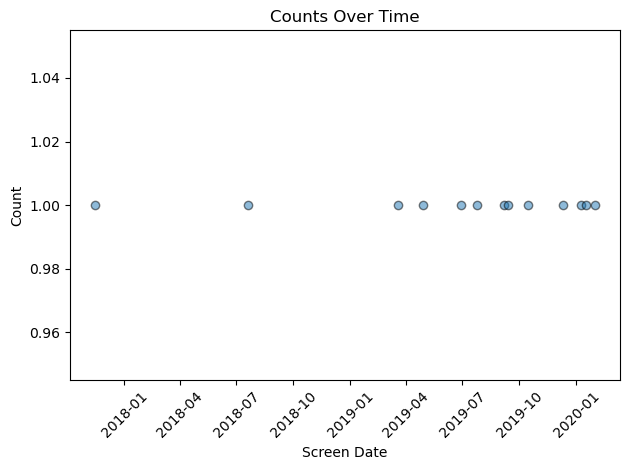

In [110]:
df_plot = df_discrepant.query("mix_phylotypes in ['2.2.M4.4,3.1.1.1,4.3.2.1', '2.2.M4.4,4.1.1.1,4.3.2.1']")

plt.scatter(df_plot["screen_date"], df_plot["Count"], marker="o", alpha=0.5, linewidth=1, edgecolor='black')
plt.xlabel("Screen Date")
plt.ylabel("Count")
plt.title("Counts Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [318]:
def get_tbtyper_present_SNPs(sample):
    
    vcf_fName = f"{DS_dir}/{sample}/TBtypeR/{sample}.filtered.vcf.gz"
    
    mix_phylotypes = df_combined_lineage_results.query("Sample==@sample").mix_phylotypes.values[0].split(',')

    df_lineage_variants = pd.DataFrame(columns = ['POS', 'REF', 'ALT', 'REF_DEPTH', 'ALT_DEPTH'])
    i = 0

    vcf_reader = vcf.Reader(filename=vcf_fName, compressed=True)

    for record in vcf_reader:

        if record.POS in tbtyper_SNPs_by_lineage.POS.values:

            assert len(record.samples[0]['AD']) == 2
            ref_depth, alt_depth = record.samples[0]['AD']

            if alt_depth > 0:
                df_lineage_variants.loc[i, :] = [record.POS, record.REF, str(record.ALT[0]), ref_depth, alt_depth]
                i += 1

    df_lineage_variants['AF'] = df_lineage_variants['ALT_DEPTH'] / (df_lineage_variants['REF_DEPTH'] + df_lineage_variants['ALT_DEPTH'])

    df_lineage_variants = df_lineage_variants.merge(tbtyper_SNPs_by_lineage, on=['POS', 'REF', 'ALT']).query("AF >= 0.05")
    
    del_cols = ['chrom', 'genotype', 'reference']
    
    for col in del_cols:
        if col in df_lineage_variants.columns:
            del df_lineage_variants[col]
            
    df_lineage_variants['Sample'] = sample
    
    return df_lineage_variants

In [319]:
df_lineage_variants_combined = []

for sample in df_discrepant.Sample.unique():
    
    df_lineage_variants_combined.append(get_tbtyper_present_SNPs(sample))
    
df_lineage_variants_combined = pd.concat(df_lineage_variants_combined)

# dummy for matrix
df_lineage_variants_combined['Variant'] = 1

df_lineage_variants_combined['DP'] = df_lineage_variants_combined['REF_DEPTH'] + df_lineage_variants_combined['ALT_DEPTH']

df_lineage_variants_combined = df_lineage_variants_combined.query("DP >= 10").reset_index(drop=True)

In [320]:
df_samples_with_variant = pd.DataFrame(df_lineage_variants_combined.groupby('POS')['Sample'].nunique()).reset_index()

pos_in_every_sample = df_samples_with_variant.query("Sample==@df_lineage_variants_combined.Sample.nunique()").POS.values

In [321]:
tbtyper_SNPs_by_lineage.query("POS in @pos_in_every_sample").phylotype.unique()

array(['4.9'], dtype=object)

In [322]:
df_lineage_variants_combined_no_Rv = df_lineage_variants_combined.query("phylotype != '4.9'")

lineage_variants_matrix = df_lineage_variants_combined_no_Rv.pivot(index='Sample', columns='POS', values='AF').fillna(0)

In [323]:
df_samples_with_variant = pd.DataFrame(df_lineage_variants_combined_no_Rv.groupby('POS')['Sample'].nunique()).reset_index()

pos_in_almost_every_sample = df_samples_with_variant.query("Sample==@df_lineage_variants_combined.Sample.nunique()-1").POS.values

In [324]:
tbtyper_SNPs_by_lineage.query("POS in @pos_in_almost_every_sample").phylotype.value_counts()

phylotype
4        10
2         9
2.2       5
2.2.1     2
Name: count, dtype: int64

In [325]:
df_discrepant_split_lineages = pd.concat([df_discrepant[['pid', 'Sample', 'Original_ID']],
                                           df_discrepant['mix_phylotypes'].str.split(',', expand=True),
                                           df_discrepant['mix_props'].str.split(',', expand=True),
                                          ], axis=1)

id_cols = ['pid', 'Sample', 'Original_ID']

df_discrepant_split_lineages.columns = id_cols + ['Lineage_1', 'Lineage_2', 'Lineage_3', 'Prop_1', 'Prop_2', 'Prop_3']

weird_samples = df_discrepant.query("mix_phylotypes in ['2.2.M4.4,3.1.1.1,4.3.2.1', '2.2.M4.4,4.1.1.1,4.3.2.1']").Sample.values
print(len(weird_samples))

df_discrepant_split_lineages = df_discrepant_split_lineages.query("Sample in @weird_samples")

# Melt lineage
df_lineage = (
    df_discrepant_split_lineages[id_cols + lineage_cols]
    .melt(id_vars=id_cols, var_name="Lineage_idx", value_name="Lineage")
)

# Melt prop
df_prop = (
    df_discrepant_split_lineages[id_cols + prop_cols]
    .melt(id_vars=id_cols, var_name="Prop_idx", value_name="Prop")
)

# Extract numeric index (1, 2, 3)
df_lineage["idx"] = df_lineage["Lineage_idx"].str.extract(r"(\d+)")
df_prop["idx"]    = df_prop["Prop_idx"].str.extract(r"(\d+)")

# Merge on IDs + index
df_long = (
    df_lineage.merge(df_prop, on=id_cols + ["idx"])
              .sort_values(id_cols + ["idx"])
              .reset_index(drop=True)
)

# Optional: drop unused columns
df_long = df_long[id_cols + ["Lineage", "Prop"]]
df_long['Prop'] = df_long['Prop'].astype(float)

13


<Axes: xlabel='Lineage', ylabel='Prop'>

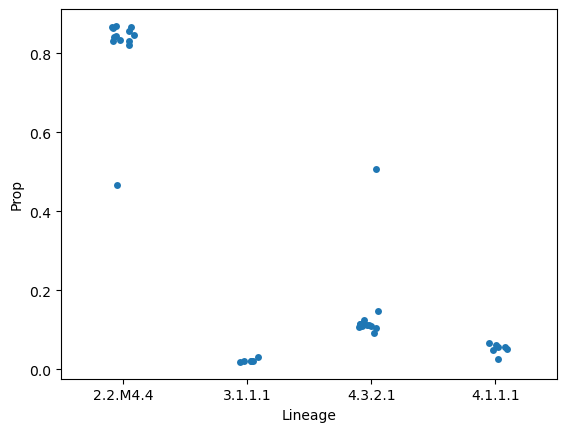

In [326]:
sns.stripplot(data=df_long,
              x='Lineage',
              y='Prop'
             )

In [327]:
lineage_variants_matrix = df_lineage_variants_combined_no_Rv.query("Sample in @weird_samples & phylotype not in ['4', '2', '2.2', '2.2.1']").pivot(index='Sample', columns='POS', values='Variant').fillna(0)


lineage_variants_AF_matrix = df_lineage_variants_combined_no_Rv.query("Sample in @weird_samples & phylotype not in ['4', '2', '2.2', '2.2.1']").pivot(index='Sample', columns='POS', values='AF').fillna(0)

In [328]:
weird_samples_1 = df_discrepant.query("mix_phylotypes in ['2.2.M4.4,4.1.1.1,4.3.2.1'] & Sample != 'S0184-01'").Sample.values
weird_samples_2 = df_discrepant.query("mix_phylotypes in ['2.2.M4.4,3.1.1.1,4.3.2.1']").Sample.values

num_weird_1 = len(weird_samples_1)
num_weird_2 = len(weird_samples_2)

print(num_weird_1, num_weird_2)

6 6


In [329]:
variants_in_all_sample1 = pd.DataFrame(df_lineage_variants_combined_no_Rv.query("Sample in @weird_samples_1").groupby('POS').Sample.nunique().sort_values()).query("Sample==@num_weird_1").index.values
variants_in_all_sample2 = pd.DataFrame(df_lineage_variants_combined_no_Rv.query("Sample in @weird_samples_2").groupby('POS').Sample.nunique().sort_values()).query("Sample==@num_weird_2").index.values

In [330]:
len(variants_in_all_sample1), len(variants_in_all_sample2)

(275, 284)

In [331]:
df_lineage_variants_combined_no_Rv.query("Sample in @weird_samples_1 & POS in @variants_in_all_sample1")#.phylotype.value_counts()

,POS,REF,ALT,REF_DEPTH,ALT_DEPTH,AF,phylotype,Sample,Variant,DP
423,5520,C,T,244,14,0.054264,4.3.2.1,S0089-01,1,258
426,25295,C,T,48,133,0.734807,2.2.M4.4,S0089-01,1,181
427,36008,G,C,27,169,0.862245,2,S0089-01,1,196
428,38712,C,T,40,143,0.781421,2.2.M4.4,S0089-01,1,183
429,39158,C,G,33,172,0.839024,2,S0089-01,1,205
...,...,...,...,...,...,...,...,...,...,...
4033,4329782,G,A,2,19,0.904762,4,S0188-01,1,21
4038,4362568,T,G,3,12,0.8,2,S0188-01,1,15
4042,4388153,G,A,20,2,0.090909,4.3.2.1,S0188-01,1,22
4043,4389202,C,T,15,3,0.166667,4.3.2,S0188-01,1,18


In [332]:
lineage_variants_matrix.loc[weird_samples_1]

POS,5520,7222,11370,14251,25295,29641,38712,41257,43191,46892,...,4350446,4357123,4370038,4375480,4384417,4385530,4386709,4387525,4388153,4389202
Sample,,,,,,,,,,,,,,,,,,,,,
S0089-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
S0150-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
S0157-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
S0170-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
S0180-01,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
S0188-01,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [333]:
lineage_variants_matrix.loc[weird_samples_2]

POS,5520,7222,11370,14251,25295,29641,38712,41257,43191,46892,...,4350446,4357123,4370038,4375480,4384417,4385530,4386709,4387525,4388153,4389202
Sample,,,,,,,,,,,,,,,,,,,,,
S0030-01,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
S0201-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
S0209-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
S0214-01,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
S0220-01,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
S0223-01,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [335]:
df_trust_patients.query("pid=='T0252'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week,Num_Culture_Samples
697,T0252,S0252-01,MFS-168,MFS-168_lib47347,NaN,NaN,1.0,384.26,1.0,0.9817,...,NaN,1.0,4.459583,NaN,0.477297,"4.1.1.3,2.2.1.1","4.1.i1.2.1,2.2.1.1.1","2,4",1,1.0


<Axes: xlabel='POS', ylabel='Sample'>

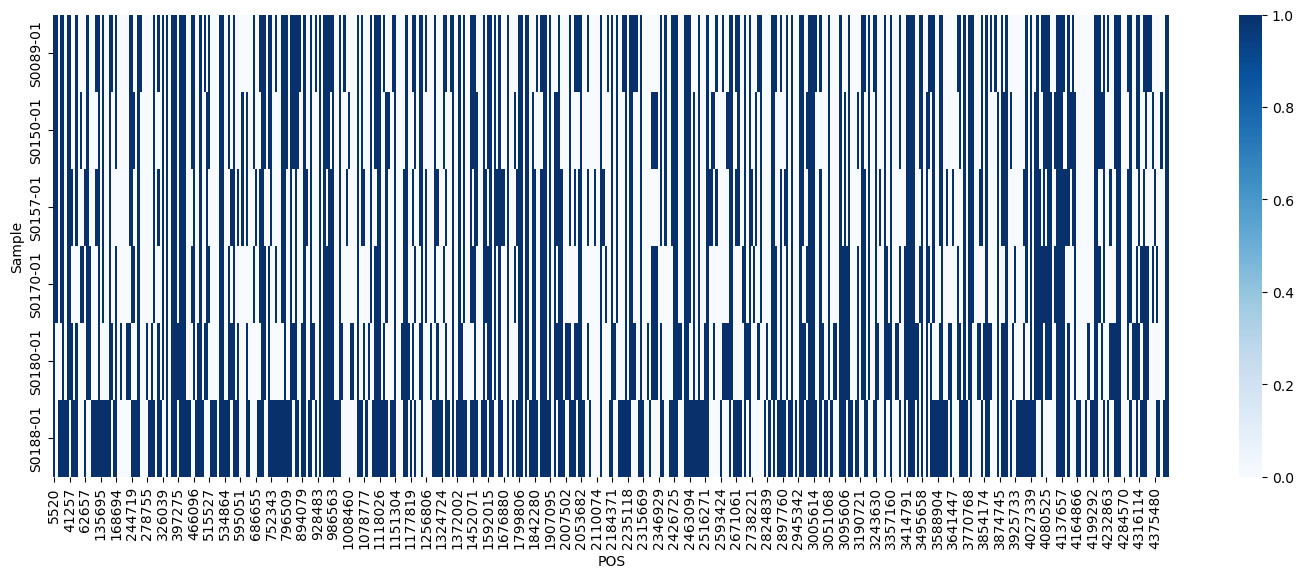

In [277]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(lineage_variants_matrix.loc[weird_samples_1], cmap='Blues')

<Axes: xlabel='POS', ylabel='Sample'>

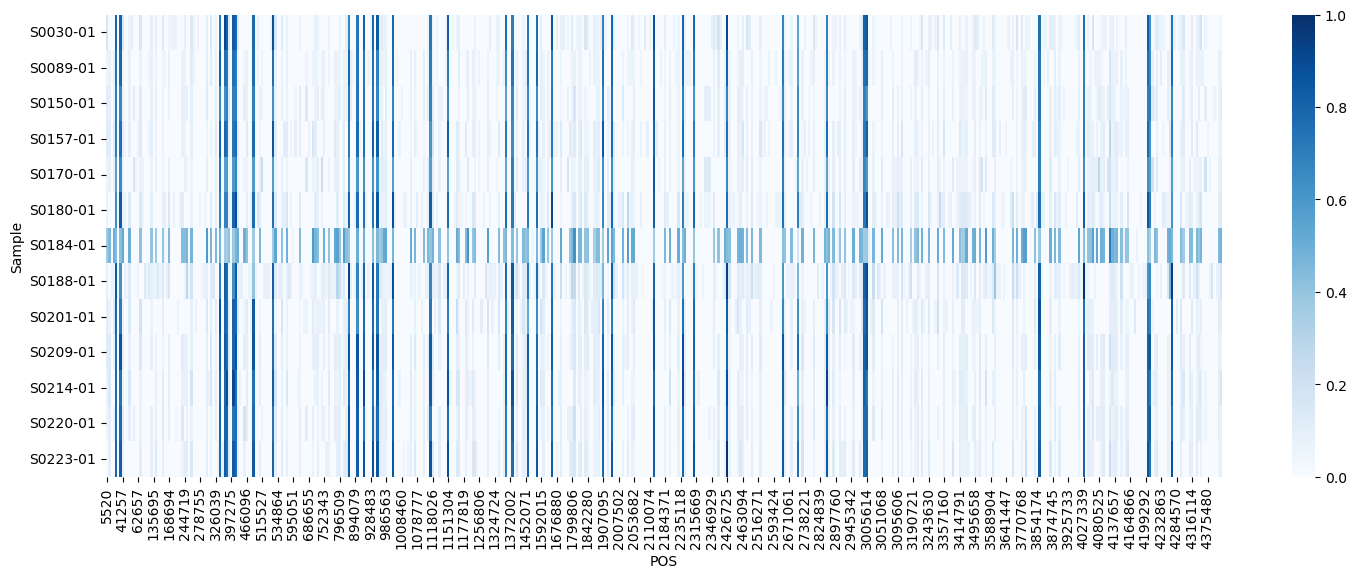

In [241]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.heatmap(lineage_variants_matrix, cmap='Blues')

In [153]:
(lineage_variants_matrix > 0).sum(axis=0).sort_values()

POS
4384        1
2185884     1
2186236     1
2190367     1
2194324     1
           ..
1759252    22
2779136    22
188800     22
384380     22
261869     22
Length: 1331, dtype: int64

In [128]:
tbtyper_SNPs_by_lineage.query("genotype==0").phylotype.value_counts()

phylotype
4      94
4.9    37
Name: count, dtype: int64

In [125]:
df_lineage_variants

,POS,REF,ALT,REF_DEPTH,ALT_DEPTH,AF,chrom,genotype,phylotype,reference
0,5520,C,T,29,6,0.171429,AL123456.3,1,4.3.2.1,Napier et al. 2020
8,25295,C,T,6,23,0.793103,AL123456.3,1,2.2.M4.4,Thawornwattana et al. 2021
11,36008,G,C,7,37,0.840909,AL123456.3,1,2,Napier et al. 2020
12,38712,C,T,6,24,0.8,AL123456.3,1,2.2.M4.4,Thawornwattana et al. 2021
13,39158,C,G,8,23,0.741935,AL123456.3,1,2,Napier et al. 2020
...,...,...,...,...,...,...,...,...,...,...
740,4356110,G,C,0,35,1.0,AL123456.3,0,4.9,Napier et al. 2020
742,4362568,T,G,3,27,0.9,AL123456.3,1,2,Napier et al. 2020
743,4370038,G,T,31,2,0.060606,AL123456.3,1,2.2.M1.1,Thawornwattana et al. 2021
744,4389202,C,T,38,2,0.05,AL123456.3,1,4.3.2,Napier et al. 2020


In [96]:
df_trust_patients.columns[df_trust_patients.columns.str.contains('date')]

Index(['screen_date', 'screen_icdate', 'screen_pregdate', 'screen_hivdate',
       'screen_pkicdate', 'screen_crfdate', 'screen_verdate',
       'screen_datadate', 'screen_date_add_additional_visit2',
       'screen_date_add_additional_visit',
       ...
       'covid_newdose3date_est___1_treatment_6mo', 'covid_2_crfdate_baseline',
       'covid_2_crfdate_posttreatment_12mo', 'covid_2_crfdate_treatment_6mo',
       'covid_2_verdate_baseline', 'covid_2_verdate_posttreatment_12mo',
       'covid_2_verdate_treatment_6mo', 'covid_2_datadate_baseline',
       'covid_2_datadate_posttreatment_12mo',
       'covid_2_datadate_treatment_6mo'],
      dtype='object', length=734)

,pid,screen_date
0,T0099,2018-08-22
1,T0099,2018-08-22
2,T0099,2018-08-22
3,T0397,2023-02-09
4,T0397,2023-02-09
...,...,...
762,T0297,2021-09-10
763,T0290,2021-08-27
764,T0290,2021-08-27
765,T0312,2021-11-19


In [83]:
tbtyper_SNPs_by_lineage.query("phylotype=='2.2.M1.1'")

,chrom,POS,REF,ALT,genotype,phylotype,reference
222,AL123456.3,57298,C,G,1,2.2.M1.1,Thawornwattana et al. 2021
1497,AL123456.3,515527,G,A,1,2.2.M1.1,Thawornwattana et al. 2021
1865,AL123456.3,671385,C,G,1,2.2.M1.1,Thawornwattana et al. 2021
2028,AL123456.3,731015,A,G,1,2.2.M1.1,Thawornwattana et al. 2021
4583,AL123456.3,1770945,C,T,1,2.2.M1.1,Thawornwattana et al. 2021
6002,AL123456.3,2336125,T,G,1,2.2.M1.1,Thawornwattana et al. 2021
6003,AL123456.3,2336129,A,G,1,2.2.M1.1,Thawornwattana et al. 2021
6004,AL123456.3,2336130,A,G,1,2.2.M1.1,Thawornwattana et al. 2021
8797,AL123456.3,3535572,C,A,1,2.2.M1.1,Thawornwattana et al. 2021
9948,AL123456.3,4080525,C,T,1,2.2.M1.1,Thawornwattana et al. 2021


In [45]:
record.samples[0]['AD']

[16, 0]

In [48]:
df_full = df_tbtyper_culture.merge(df_tbtyper, on='Original_ID', how='left')
print(df_full.dropna(subset='mix_phylotypes').Original_ID.nunique())
len(set(df_full.dropna(subset='mix_phylotypes').Original_ID) - set(df_combined_lineage_results.Original_ID))

163


0

In [109]:
weird_samples = df_combined_lineage_results.query("Match==1 & Exact_Match==0 & cult_mix_phylotypes=='2.2.M1.1' & mix_phylotypes in ['2.2.M4.4,4.1.1.1,4.3.2.1', '2.2.M4.4,3.1.1.1,4.3.2.1']")[['Original_ID', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Median_Depth']].Original_ID.values

df_combined_lineage_results.query("Match==1 & Exact_Match==0 & cult_mix_phylotypes=='2.2.M1.1' & mix_phylotypes in ['2.2.M4.4,4.1.1.1,4.3.2.1', '2.2.M4.4,3.1.1.1,4.3.2.1']")[['Original_ID', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Median_Depth']]

,Original_ID,cult_mix_phylotypes,cult_mix_props,mix_phylotypes,mix_props,Median_Depth
146,S0089-01,2.2.M1.1,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8408,0.0667,0.0925",303.0
234,S0150-01,2.2.M1.1,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8464,0.0477,0.1059",163.0
266,S0170-01,2.2.M1.1,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8439,0.0514,0.1047",215.0
284,S0180-01,2.2.M1.1,1.0,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8295,0.0603,0.1102",50.0
329,S0209-01,2.2.M1.1,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8689,0.0183,0.1128",260.0
338,S0214-01,2.2.M1.1,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8663,0.0198,0.1139",99.0
347,S0220-01,2.2.M1.1,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8639,0.0207,0.1154",205.0
353,S0223-01,2.2.M1.1,1.0,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8664,0.0211,0.1125",84.0


In [137]:
df_tbtyper_culture.query("pid=='T0089'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
390,MFS-54,2.2.M1.1,1.0,1,1,T0089,S0089-01,1,0.010112,2.2.1.1,1.0,1


In [138]:
df_tbtyper_culture.query("pid=='T0150'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
595,MFS-74,2.2.M1.1,1.0,1,1,T0150,S0150-01,1,0.011030,2.2.1.1,2.0,1
603,MFS-75,2.2.M1.1,1.0,1,1,T0150,S0150-06,6,0.011409,2.2.1.1,2.0,2


In [110]:
df_trust_patients.query("Original_ID in @weird_samples")[['SampleID']]

,SampleID
554,MFS-88
555,MFS-275
556,MFS-123
599,MFS-54
661,MFS-97
676,MFS-129
687,MFS-74
692,MFS-132
707,MFS-119


In [117]:
df_trust_patients.query("Original_ID==@sample_ID")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week,Num_Culture_Samples
692,T0223,S0223-01,MFS-132,MFS-132_lib47311,NaN,NaN,1.0,372.73,0.99,0.9888,...,NaN,3.0,0.945925,NaN,0.010359,2.2.1.1,2.2.1.1.1,2,1,1.0


In [135]:
sample_ID = "S0150-01"
fName = f"{DS_dir}/{sample_ID}/TBtypeR/{sample_ID}.filtered.tsv"
candidate_lineages = df_combined_lineage_results.query("Original_ID==@sample_ID").mix_phylotypes.values[0].split(',')

candidate_lineages = candidate_lineages + df_combined_lineage_results.query("Original_ID==@sample_ID").cult_mix_phylotypes.values[0].split(',')

df_tbtyper_SNPs_single_sample = pd.read_csv(fName, sep='\t', header=None, names=['POS', 'REF', 'ALT', 'QUAL', 'AD'])

df_AD = df_tbtyper_SNPs_single_sample['AD'].str.split(',', expand=True).astype(int)
df_AD.columns = ['REF_AD', 'ALT_AD']

df_tbtyper_SNPs_single_sample = pd.concat([df_tbtyper_SNPs_single_sample, df_AD], axis=1)

df_tbtyper_SNPs_single_sample['ALT_AF'] = df_tbtyper_SNPs_single_sample['ALT_AD'] / (df_tbtyper_SNPs_single_sample['REF_AD'] + df_tbtyper_SNPs_single_sample['ALT_AD'])

ALT_read_thresh = 4
    
for lineage in candidate_lineages:
    
    df_lineage_SNPs = tbtyper_SNPs_by_lineage.query("phylotype==@lineage")

    avg_AF = df_tbtyper_SNPs_single_sample.query("POS in @df_lineage_SNPs.pos & ALT_AD >= @ALT_read_thresh").ALT_AF.mean()
    num_SNPs = len(df_tbtyper_SNPs_single_sample.query("POS in @df_lineage_SNPs.pos & ALT_AD >= @ALT_read_thresh"))
    
    print(f"L{lineage}: {num_SNPs} SNPs, AF = {np.round(avg_AF, 2)}")

L2.2.M4.4: 34 SNPs, AF = 0.68
L4.1.1.1: 17 SNPs, AF = 0.04
L4.3.2.1: 50 SNPs, AF = 0.08
L2.2.M1.1: 12 SNPs, AF = 0.1


In [136]:
sample_ID = "S0089-01"
fName = f"{DS_dir}/{sample_ID}/TBtypeR/{sample_ID}.filtered.tsv"
candidate_lineages = df_combined_lineage_results.query("Original_ID==@sample_ID").mix_phylotypes.values[0].split(',')

candidate_lineages = candidate_lineages + df_combined_lineage_results.query("Original_ID==@sample_ID").cult_mix_phylotypes.values[0].split(',')

df_tbtyper_SNPs_single_sample = pd.read_csv(fName, sep='\t', header=None, names=['POS', 'REF', 'ALT', 'QUAL', 'AD'])

df_AD = df_tbtyper_SNPs_single_sample['AD'].str.split(',', expand=True).astype(int)
df_AD.columns = ['REF_AD', 'ALT_AD']

df_tbtyper_SNPs_single_sample = pd.concat([df_tbtyper_SNPs_single_sample, df_AD], axis=1)

df_tbtyper_SNPs_single_sample['ALT_AF'] = df_tbtyper_SNPs_single_sample['ALT_AD'] / (df_tbtyper_SNPs_single_sample['REF_AD'] + df_tbtyper_SNPs_single_sample['ALT_AD'])

ALT_read_thresh = 4
    
for lineage in candidate_lineages:
    
    df_lineage_SNPs = tbtyper_SNPs_by_lineage.query("phylotype==@lineage")

    avg_AF = df_tbtyper_SNPs_single_sample.query("POS in @df_lineage_SNPs.pos & ALT_AD >= @ALT_read_thresh").ALT_AF.mean()
    num_SNPs = len(df_tbtyper_SNPs_single_sample.query("POS in @df_lineage_SNPs.pos & ALT_AD >= @ALT_read_thresh"))
    
    print(f"L{lineage}: {num_SNPs} SNPs, AF = {np.round(avg_AF, 2)}")

L2.2.M4.4: 34 SNPs, AF = 0.74
L4.1.1.1: 36 SNPs, AF = 0.04
L4.3.2.1: 52 SNPs, AF = 0.07
L2.2.M1.1: 11 SNPs, AF = 0.05


In [173]:
h37Rv_regions.query("Name=='rrf'")

,Refseq_ID,Mycobrowser_Version,Feature,Start,Stop,Score,Strand,Frame,Locus,Name,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
1420,NC_000962.3,Mycobrowser_v4,rRNA,1476899,1477013,.,+,0.0,MTB000021,rrf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [168]:
tbtyper_SNPs_by_lineage.query("pos >= 759807 & pos <= 763325")

,chrom,pos,ref,alt,genotype,phylotype,reference
2092,AL123456.3,759956,C,A,1,4.8.3,Napier et al. 2020
2093,AL123456.3,760969,C,T,1,6,Napier et al. 2020
2094,AL123456.3,761723,A,C,1,6,Napier et al. 2020
2095,AL123456.3,762434,T,G,1,3,Napier et al. 2020
2096,AL123456.3,763094,G,T,1,La1.7.X-unk5,Zwyer et al. 2021


In [174]:
tbtyper_SNPs_by_lineage.query("pos >= 1476899 & pos <= 1477013")

,chrom,pos,ref,alt,genotype,phylotype,reference


In [175]:
exclude_regions = ['clpB', 'hsp', 'rpoB', 'rpoC', 'tuf', 'rpsC', 'aspT', 'rrs', 'rrl']

In [177]:
assert len(h37Rv_regions.query("Name in @exclude_regions")) == len(exclude_regions)

In [186]:
exclude_pos = []

for i, row in h37Rv_regions.query("Name in @exclude_regions").iterrows():
    
    exclude_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
len(exclude_pos)

17262

In [188]:
tbtyper_SNPs_by_lineage.query("pos in @exclude_pos").phylotype.value_counts()

phylotype
La3             4
6               2
7               2
5.1.5           1
6.3.1           1
4.8.3           1
3               1
La1.7.X-unk5    1
1.2.2           1
La1.2.BCG       1
3.5.1           1
4.3             1
4.1             1
1.1.3           1
8               1
Name: count, dtype: int64

In [189]:
tbtyper_SNPs_by_lineage.query("pos in @exclude_pos")

,chrom,pos,ref,alt,genotype,phylotype,reference
951,AL123456.3,302191,G,T,1,5.1.5,Coscolla et al. 2021
952,AL123456.3,302241,C,T,1,La3,Zwyer et al. 2021
953,AL123456.3,302245,C,T,1,La3,Napier et al. 2020
1350,AL123456.3,459600,C,A,1,La3,Zwyer et al. 2021
1351,AL123456.3,461439,G,A,1,6.3.1,Coscolla et al. 2021
2092,AL123456.3,759956,C,A,1,4.8.3,Napier et al. 2020
2093,AL123456.3,760969,C,T,1,6,Napier et al. 2020
2094,AL123456.3,761723,A,C,1,6,Napier et al. 2020
2095,AL123456.3,762434,T,G,1,3,Napier et al. 2020
2096,AL123456.3,763094,G,T,1,La1.7.X-unk5,Zwyer et al. 2021


In [185]:
row['Start'], row['Stop']

(1473658, 1476795)

In [163]:
pid = 'T0167'
df_tbtyper.query("pid==@pid")

,Sample,Original_ID,mix_phylotypes,mix_props,n_phy,defaultParams,pid,Median_Depth


In [164]:
df_tbtyper_culture.query("pid==@pid")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
693,MFS-84,"2.2.M2.2,4.1.1.3","0.824,0.176",2,1,T0167,S0167-01,1,0.177757,2.2.1,2.0,1
704,MFS-85,"2.2.M2.2,4.1.1.3","0.7425,0.2575",2,1,T0167,S0167-04,4,0.259418,"2.2.1,4.1.1.3",2.0,2


In [152]:
df_tbtyper.query("pid=='T0204'")

,Sample,Original_ID,mix_phylotypes,mix_props,n_phy,defaultParams,pid,Median_Depth


In [154]:
df_tbtyper_culture.query("pid=='T0204'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
485,MFS-630,"2.2.M4.4,3.1.1.1","0.8577,0.1423",2,1,T0204,S0204-01,1,0.147559,2.2.1,2.0,1
486,MFS-631,"2.2.M4.4,3.1.1.1","0.6952,0.3048",2,1,T0204,S0204-08,8,0.314259,"2.2.1,3.1.1",2.0,2


In [139]:
lineage = '4.3.2.1'
df_lineage_SNPs = tbtyper_SNPs_by_lineage.query("phylotype==@lineage")
df_tbtyper_SNPs_single_sample.query("POS in @df_lineage_SNPs.pos & ALT_AD >= 2")

,POS,REF,ALT,QUAL,AD,REF_AD,ALT_AD,ALT_AF
13,5520,C,T,20.2820,"244,14",244,14,0.054264
20,7222,C,T,20.3698,"237,18",237,18,0.070588
269,69025,G,C,20.3433,"217,16",217,16,0.068670
481,147655,G,C,20.3060,"205,15",205,15,0.068182
537,168694,G,T,20.3903,"167,15",167,15,0.082418
765,244719,G,A,20.3303,"172,12",172,12,0.065217
817,265154,G,C,20.4693,"167,20",167,20,0.106952
1118,392914,C,T,20.4497,"189,18",189,18,0.086957
1198,429247,C,T,20.2591,"183,12",183,12,0.061538
1269,457032,T,C,20.2614,"166,9",166,9,0.051429


In [119]:
df_lineage_SNPs

,chrom,pos,ref,alt,genotype,phylotype,reference
731,AL123456.3,225274,T,C,1,3.1.1.1,Shuaib et al. 2022
879,AL123456.3,278755,C,T,1,3.1.1.1,Shuaib et al. 2022
934,AL123456.3,294514,T,C,1,3.1.1.1,Shuaib et al. 2022
1110,AL123456.3,363467,G,A,1,3.1.1.1,Shuaib et al. 2022
2116,AL123456.3,771094,C,A,1,3.1.1.1,Shuaib et al. 2022
2501,AL123456.3,931240,G,T,1,3.1.1.1,Shuaib et al. 2022
3068,AL123456.3,1157010,A,G,1,3.1.1.1,Shuaib et al. 2022
4851,AL123456.3,1882348,G,T,1,3.1.1.1,Shuaib et al. 2022
5422,AL123456.3,2110074,C,T,1,3.1.1.1,Shuaib et al. 2022
5678,AL123456.3,2205371,A,C,1,3.1.1.1,Shuaib et al. 2022


In [116]:
lineage = '2.2.M4.4'
df_lineage_SNPs = tbtyper_SNPs_by_lineage.query("phylotype==@lineage")
print(len(df_lineage_SNPs))
df_tbtyper_SNPs_single_sample.query("POS in @df_lineage_SNPs.pos & ALT_AD >= 2")

35


,POS,REF,ALT,QUAL,AD,REF_AD,ALT_AD,ALT_AF
103,25295,C,T,24.51830,"8,32",8,32,0.800000
154,38712,C,T,42.62780,"9,41",9,41,0.820000
1019,342061,G,C,14.69310,"10,35",10,35,0.777778
1098,385296,C,T,26.61730,"9,44",9,44,0.830189
1102,387275,C,T,15.35740,"12,38",12,38,0.760000
1141,403155,T,C,129.66700,"6,30",6,30,0.833333
1185,421187,C,T,15.35740,"13,44",13,44,0.771930
1357,492915,A,G,112.67400,"7,35",7,35,0.833333
1461,532557,C,T,15.35740,"13,49",13,49,0.790323
2224,868600,T,C,58.63260,"9,45",9,45,0.833333


In [97]:
df_tbtyper_SNPs_single_sample

,POS,REF,ALT,QUAL,AD,REF_AD,ALT_AD,ALT_AF
0,45,G,A,271.9930,"16,0",16,0,0.0
1,1131,C,A,271.9930,"34,0",34,0,0.0
2,1534,T,C,271.9930,"25,0",25,0,0.0
3,1849,C,T,17.0759,"5,0",5,0,0.0
4,1928,G,A,271.9930,"33,0",33,0,0.0
...,...,...,...,...,...,...,...,...
10324,4410229,G,T,271.9930,"34,0",34,0,0.0
10325,4410386,G,T,271.9930,"34,0",34,0,0.0
10326,4410891,C,T,271.9930,"32,0",32,0,0.0
10327,4410974,C,T,271.9930,"40,0",40,0,0.0


0.101719526168327

In [57]:
f"{DS_dir}/{sample_ID}/TBtypeR/{sample_ID}.filtered.vcf.gz"

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/S0030-01/TBtypeR/S0030-01.filtered.vcf.gz'

In [316]:
df_combined_lineage_results.query("Match == 0")[['Original_ID', 'Sampling_Week', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props']]

,Original_ID,Sampling_Week,cult_mix_phylotypes,cult_mix_props,mix_phylotypes,mix_props
153,S0096-01,1,3.1.1.1,1.0,"2.2.M4.4,4.1.1,4.3.2.1","0.1365,0.0945,0.769"
356,S0225-01,1,3.1.3.1,1.0,"2.2.M4.4,4.1.1.3,4.3.2.1","0.5994,0.1903,0.2103"


In [140]:
df_combined_lineage_results_matched = df_combined_lineage_results.query("Exact_Match != 0").sort_values('Original_ID').drop_duplicates(subset='Original_ID', keep='first').reset_index(drop=True)
del df_combined_lineage_results_matched['Match']

print(len(df_combined_lineage_results_matched), len(df_combined_lineage_results_matched.dropna(subset='mix_props')))

141 141


In [194]:
!pwd

/home/sak0914/MtbLongitudinalDiversity/direct_sputum


In [197]:
df_combined_lineage_results_matched.to_csv("./TBTypeR_full_results_matched_culture_DS.csv", index=False)

In [143]:
df_combined_lineage_results_matched.query("mix_phylotypes=='2.2.M4.4,4.1.1.1,4.3.2.1'")[['SampleID', 'cult_mix_phylotypes', 'pid', 'Original_ID', 'mix_phylotypes', 'mix_props', 'Median_Depth']]

,SampleID,cult_mix_phylotypes,pid,Original_ID,mix_phylotypes,mix_props,Median_Depth
1,MFS-4,4.1.1.1,T0008,S0008-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.7967,0.1159,0.0874",27.0
9,MFS-25,4.3.2.1,T0045,S0045-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.3351,0.0103,0.6546",194.0
11,MFS-28,4.1.1.1,T0049,S0049-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.1667,0.8142,0.0191",73.0
24,MFS-55,2.2.M4.4,T0100,S0100-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8041,0.1045,0.0914",100.0
35,MFS-81,4.3.2.1,T0162,S0162-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.4826,0.0265,0.4909",345.0
36,MFS-83,4.1.1.1,T0165,S0165-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8266,0.0638,0.1096",69.0
45,MFS-108,2.2.M4.4,T0190,S0190-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.884,0.0406,0.0754",241.0
47,MFS-194,4.1.1.1,T0192,S0192-02,"2.2.M4.4,4.1.1.1,4.3.2.1","0.2098,0.7637,0.0265",241.0
49,MFS-111,4.3.2.1,T0196,S0196-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.6066,0.037,0.3564",119.0


In [144]:
df_combined_lineage_results_matched.query("mix_phylotypes=='2.2.M4.4,3.1.1.1,4.3.2.1'")[['SampleID', 'cult_mix_phylotypes', 'pid', 'Original_ID', 'mix_phylotypes', 'mix_props', 'Median_Depth']]

,SampleID,cult_mix_phylotypes,pid,Original_ID,mix_phylotypes,mix_props,Median_Depth
6,MFS-13,4.3.2.1,T0028,S0028-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.6542,0.0169,0.3289",84.0
7,MFS-16,2.2.M4.4,T0031,S0031-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.9218,0.0119,0.0663",106.0
54,MFS-125,4.3.2.1,T0218,S0218-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.4486,0.0114,0.54",294.0
55,MFS-127,3.1.1.1,T0219,S0219-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.2819,0.6827,0.0354",740.0


In [318]:
df_same_lineage_different_props = df_combined_lineage_results_matched.query("cult_mix_phylotypes==mix_phylotypes").query("cult_n_phy > 1")[['Original_ID', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props']]
print(df_same_lineage_different_props.Original_ID.nunique())

df_same_lineage_different_props = pd.DataFrame(columns = ['Original_ID', 'lineage', 'cult_prop', 'DS_prop'])
i = 0

for original_id in df_combined_lineage_results_matched.query("cult_mix_phylotypes==mix_phylotypes").query("cult_n_phy > 1").Original_ID.values:
    
    df_single_sample = df_combined_lineage_results_matched.query("Original_ID==@original_id")
    assert len(df_single_sample) == 1
    
    cult_lineages = df_single_sample['cult_mix_phylotypes'].values[0].split(',')
    cult_props = np.array(df_single_sample['cult_mix_props'].values[0].split(',')).astype(float)
    
    DS_lineages = df_single_sample['mix_phylotypes'].values[0].split(',')
    DS_props = np.array(df_single_sample['mix_props'].values[0].split(',')).astype(float)
    
    # check ordering
    assert sum(np.array(cult_lineages) != np.array(DS_lineages)) == 0
    
    for k, lineage in enumerate(cult_lineages):
        df_same_lineage_different_props.loc[i, :] = [original_id, lineage, cult_props[k], DS_props[k]]
        i += 1
        
df_long = df_same_lineage_different_props.melt(
    id_vars=["Original_ID", "lineage"],
    value_vars=["cult_prop", "DS_prop"],
    var_name="Assay",
    value_name="Prop"
)

# Clean up names
df_long["Assay"] = df_long["Assay"].map(
    {"cult_prop": "Culture", "DS_prop": "DS"}
)

3


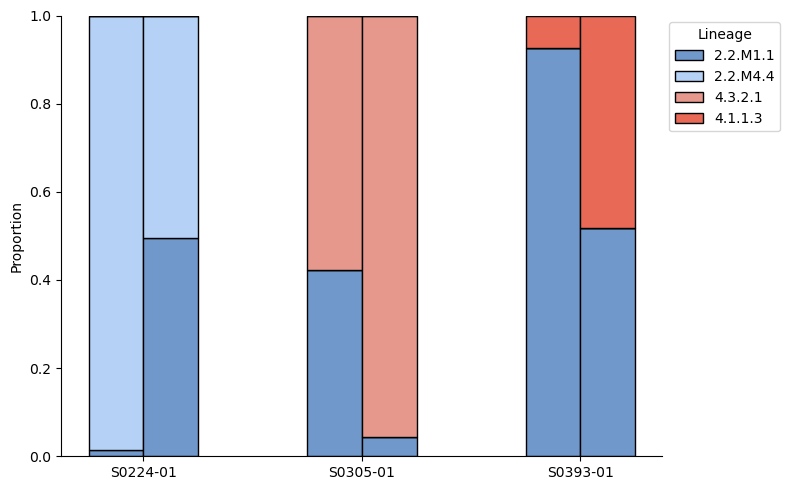

In [319]:
color_dict = {'2.2.M1.1': "#7098CB",
              '2.2.M4.4': "#b5d1f5",
              '4.1.1.3': "#E76956",
              '4.3.2.1': "#e6988c"
              }

# Unique ordering
ids = df_same_lineage_different_props["Original_ID"].unique()
lineages = df_same_lineage_different_props["lineage"].unique()
assays = ["Culture", "DS"]

# Bar positions
x = np.arange(len(ids))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for j, assay in enumerate(assays):
    # lateral offset within each group
    x_offset = x + (j - 0.5) * width
    
    # starting point for stacking
    bottoms = np.zeros(len(ids))
    
    for lineage in lineages:
        heights = [
            df_long[
                (df_long["Original_ID"] == oid) &
                (df_long["Assay"] == assay) &
                (df_long["lineage"] == lineage)
            ]["Prop"].values[0]
            if len(df_long[(df_long["Original_ID"] == oid) & (df_long["Assay"] == assay) & (df_long["lineage"] == lineage)]) == 1 else 0 for oid in ids 
        ]
        
        ax.bar(
            x_offset,
            heights,
            width,
            bottom=bottoms,
            color=color_dict[lineage],
            edgecolor='black',
            linewidth=1,
            label=f"{lineage}"
        )
        bottoms += heights

ax.set_xticks(x)
ax.set_xticklabels(ids, rotation=0)
ax.set_ylabel("Proportion")
# ax.set_title("Culture vs DS proportions by lineage")

handles, labels = ax.get_legend_handles_labels()

from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

ax.legend(by_label.values(), by_label.keys(), title="Lineage", bbox_to_anchor=(1.0, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

In [320]:
sample = 'MFS-313'

# tbtypeR result: L4.3.2.1 = 0.577, L2.2.M1.1 = 0.423

vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/pilon/{sample}_SNPs.vcf")

lineage_1 = 'lineage4.3.2.1'
lineage_2 = 'lineage2.2.1.1'

lineage_1_AF = []
lineage_2_AF = []

for record in vcf_reader:
    if record.POS in Coll_2014.query("lineage==@lineage_1").position.values:
        # print(record.POS, record.REF, record.ALT, record.INFO['AF'], "L.4.3.2.1")
        lineage_1_AF.append(record.INFO['AF'][0])
    
    if record.POS in Coll_2014.query("lineage==@lineage_2").position.values:
        # print(record.POS, record.REF, record.ALT, record.INFO['AF'], "L2.2.1.1")
        lineage_2_AF.append(record.INFO['AF'][0])
        
print(lineage_1.replace('lineage', ''), np.round(np.mean(lineage_1_AF), 2))
print(lineage_2.replace('lineage', ''), np.round(np.mean(lineage_2_AF), 2))


KeyboardInterrupt



In [221]:
sample = 'S0305-01'

vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}/pilon/{sample}_SNPs.vcf")

lineage_1 = 'lineage4.3.2.1'
lineage_2 = 'lineage2.2.1.1'

lineage_1_AF = []
lineage_2_AF = []

for record in vcf_reader:
    if record.POS in Coll_2014.query("lineage==@lineage_1").position.values:
        # print(record.POS, record.REF, record.ALT, record.INFO['AF'], "L.4.3.2.1")
        lineage_1_AF.append(record.INFO['AF'][0])
    
    if record.POS in Coll_2014.query("lineage==@lineage_2").position.values:
        # print(record.POS, record.REF, record.ALT, record.INFO['AF'], "L2.2.1.1")
        lineage_2_AF.append(record.INFO['AF'][0])
        
if len(lineage_2_AF) == 0:
    lineage_2_AF = [0]
        
print(lineage_1.replace('lineage', ''), np.round(np.mean(lineage_1_AF), 2))
print(lineage_2.replace('lineage', ''), np.round(np.mean(lineage_2_AF), 2))

4.3.2.1 0.95
2.2.1.1 0.0


# High F2 and single lineage in Brendon's November 4 table

In [247]:
Brendon_DS = pd.read_excel(f"{TRUST_dir}/processed_data/Brendon_DS_Redcap_04112025.xlsx", sheet_name=None)

if len(Brendon_DS.keys()) == 1:
    Brendon_DS = Brendon_DS[list(Brendon_DS.keys())[0]]
        
# # require that they had high enough coverage and a lineage assignment
# Brendon_DS = Brendon_DS.dropna(subset='DS_mix_phylotypes').query("Median_cov >= 10").reset_index(drop=True)

Brendon_DS['Sample_ID'] = Brendon_DS['Sample_ID'].str.replace('_', '-').str.replace('M', 'm')
Brendon_DS['Original_ID'] = Brendon_DS['Sample_ID'].str.replace('B', '')

print(f"{sum(pd.isnull(Brendon_DS['DS_F2']))}/{len(Brendon_DS)} samples do not have F2")
print(f"{Brendon_DS.PID.nunique()} pids")

Brendon_DS.loc[~pd.isnull(Brendon_DS['Sequencing Lims_K_designation']), 'Sample_ID'] = Brendon_DS.loc[~pd.isnull(Brendon_DS['Sequencing Lims_K_designation'])]['Sample_ID'] + '_' + Brendon_DS.loc[~pd.isnull(Brendon_DS['Sequencing Lims_K_designation'])]['Sequencing Lims_K_designation'].str[:-1]


Brendon_DS.loc[Brendon_DS['Sample_ID'].str.contains('B'), 'Sample_ID'] = Brendon_DS.loc[Brendon_DS['Sample_ID'].str.contains('B')]['Sample_ID'].str.split('_').str[0]

44/210 samples do not have F2
176 pids


In [248]:
Brendon_DS_high_F2_single_tbtyper_lineage = Brendon_DS.query("DS_lineage_catagory != 'Mixed' & DS_F2 > 0.2").dropna(subset='DS_mix_phylotypes')[['Original_ID', 'Sample_ID', 'MFS_ID', 'DS_lineage_catagory', 'DS_mix_phylotypes', 'DS_mix_props', 'DS_F2']].sort_values('DS_F2', ascending=False)
print(len(Brendon_DS_high_F2_single_tbtyper_lineage), Brendon_DS_high_F2_single_tbtyper_lineage.Original_ID.nunique())

Brendon_DS_high_F2_single_tbtyper_lineage.sort_values('Original_ID')


13 12


,Original_ID,Sample_ID,MFS_ID,DS_lineage_catagory,DS_mix_phylotypes,DS_mix_props,DS_F2
41,S0143-01,S0143-01,MFS-72,single_lineage,4.3,1,0.299181
45,S0161-01,S0161-01,MFS-80,single_lineage,4,1,0.247841
50,S0171-01,S0171-01,MFS-90,single_lineage,4.3,1,0.248441
99,S0258-01,S0258-01,MFS-176,single_lineage,4.3,1,0.328134
118,S0279-01,S0279-01_K064745,MFS-298,single_lineage,4.3,1,0.226586
119,S0279-01,S0279-01,MFS-298,single_lineage,4.3,1,0.215332
121,S0279-06,S0279-06_K064731,MFS-299,NaN,4,1,0.419839
130,S0291-09,S0291-09,MFS-309,single_lineage,4.1.2,1,0.451736
147,S0326-01,S0326-01B,MFS-390,single_lineage,4.8.1,1,0.261391
148,S0329-01,S0329-01,MFS-393,single_lineage,4.3,1,0.304734


In [249]:
# df_compare_highF2_single_lineage = pd.concat([Brendon_DS_high_F2_single_tbtyper_lineage.merge(df_combined_lineage_results[['Original_ID', 'Sample', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Exact_Match']], left_on='Sample_ID', right_on='Sample', how='inner')
# ,
#                                              Brendon_DS_high_F2_single_tbtyper_lineage.merge(df_tbtyper.query("Sample in ['S0340-01', 'S0348-01', 'S0326-01B']")[['Sample', 'Original_ID', 'mix_phylotypes', 'mix_props']], left_on='Sample_ID', right_on='Sample', how='inner')
# ])


df_compare_highF2_single_lineage = Brendon_DS_high_F2_single_tbtyper_lineage.merge(df_tbtyper[['Original_ID', 'Sample', 'mix_phylotypes', 'mix_props']], left_on='Sample_ID', right_on='Sample', how='inner')


df_compare_highF2_single_lineage = pd.concat([df_compare_highF2_single_lineage, 
                                              Brendon_DS_high_F2_single_tbtyper_lineage.query("Sample_ID not in @df_compare_highF2_single_lineage.Sample_ID").merge(df_tbtyper[['Sample', 'Original_ID', 'mix_phylotypes', 'mix_props']], left_on='Original_ID', right_on='Sample', how='inner')]
                                            )

df_compare_highF2_single_lineage = pd.concat([df_compare_highF2_single_lineage, 
                                              Brendon_DS_high_F2_single_tbtyper_lineage.query("Sample_ID not in @df_compare_highF2_single_lineage.Sample_ID").merge(df_tbtyper[['Sample', 'Original_ID', 'mix_phylotypes', 'mix_props']], left_on='Sample_ID', right_on='Sample', how='inner')]
                                            ).sort_values('Original_ID_x')

df_compare_highF2_single_lineage.rename(columns={'Original_ID_x': 'Original_ID'}, inplace=True)

# add culture results
df_compare_highF2_single_lineage = df_compare_highF2_single_lineage.merge(df_tbtyper_culture[['SampleID', 'cult_mix_phylotypes', 'cult_mix_props']], left_on='MFS_ID', right_on='SampleID', how='left')

len(df_compare_highF2_single_lineage), df_compare_highF2_single_lineage.Sample_ID.nunique()

(13, 13)

In [250]:
df_compare_highF2_single_lineage[['Original_ID', 'MFS_ID', 'Sample', 'DS_F2', 'DS_mix_phylotypes', 'DS_mix_props', 'mix_phylotypes', 'mix_props', 'cult_mix_phylotypes', 'cult_mix_props']]



,Original_ID,MFS_ID,Sample,DS_F2,DS_mix_phylotypes,DS_mix_props,mix_phylotypes,mix_props,cult_mix_phylotypes,cult_mix_props
0,S0143-01,MFS-72,S0143-01,0.299181,4.3,1,"2.2.M4.4,4.3.2.1,4.3.3","0.1894,0.0209,0.7897",4.3.3,1.0
1,S0161-01,MFS-80,S0161-01,0.247841,4,1,"2.2.M1.1,4.3.2.1,4.8","0.1036,0.2108,0.6856",2.2.M1.1,1.0
2,S0171-01,MFS-90,S0171-01,0.248441,4.3,1,"2.2.M1.1,4.1.1.1,4.3.2.1","0.0737,0.0429,0.8834",4.3.2.1,1.0
3,S0258-01,MFS-176,S0258-01,0.328134,4.3,1,"2.2.M2.5,4.1.1.1,4.3.2.1","0.1727,0.035,0.7923",4.3.2.1,1.0
4,S0279-01,MFS-298,S0279-01_K064745,0.226586,4.3,1,"2.2.M4.4,4.3.2.1,4.9","0.0283,0.8709,0.1008",4.3.2.1,1.0
5,S0279-01,MFS-298,S0279-01,0.215332,4.3,1,"4.1.1.1,4.3.2.1","0.0661,0.9339",4.3.2.1,1.0
6,S0279-06,MFS-299,S0279-06_K064731,0.419839,4,1,"2.2.AA1,4.3.2.1,4.9","0.1428,0.3498,0.5074",4.3.2.1,1.0
7,S0291-09,MFS-309,S0291-09,0.451736,4.1.2,1,"4.1.1.1,4.1.2","0.1459,0.8541",4.1.2,1.0
8,S0326-01,MFS-390,S0326-01B,0.261391,4.8.1,1,"2.2.M4,4.8.1,4.9","0.0425,0.9061,0.0514","2.2.M1.1,4.8.1","0.0385,0.9615"
9,S0329-01,MFS-393,S0329-01,0.304734,4.3,1,"4.1.1.1,4.3.2.1","0.144,0.856",4.3.2.1,1.0


In [251]:
samples_high_F2_single_tbtyper_lineage = Brendon_DS.query("DS_lineage_catagory != 'Mixed' & DS_F2 > 0.2").dropna(subset='DS_mix_phylotypes').Original_ID.unique()
len(samples_high_F2_single_tbtyper_lineage)

12

In [252]:
df_check_culture_lineages = Brendon_DS[['MFS_ID', 'Cult_mix_phylotypes']].merge(df_trust_patients[['Original_ID', 'SampleID', 'Coll2014']], left_on='MFS_ID', right_on='SampleID', how='left')

for i, row in df_check_culture_lineages.iterrows():
    
    if not pd.isnull(row['Coll2014']) and row['Cult_mix_phylotypes'] != 'nan' and not pd.isnull(row['Cult_mix_phylotypes']):
    
        tbtyper_lineages = row['Cult_mix_phylotypes'].replace('2.2.M4.4', '2.2.1.1').replace('2.2.M4.4', '2.2.1').replace('2.2.M1.1', '2.2.1.1').split(',')
        coll2014_lineages = row['Coll2014'].split(',')

        if len(set(tbtyper_lineages).intersection(coll2014_lineages)):
            df_check_culture_lineages.loc[i, 'Match'] = 1

        else:
            tbtyper_hierarchical_lineages = list(itertools.chain.from_iterable([get_all_higher_lineages(lineage) for lineage in tbtyper_lineages]))
            coll2014_hierarchical_lineages = list(itertools.chain.from_iterable([get_all_higher_lineages(lineage) for lineage in coll2014_lineages]))

            if len(set(tbtyper_hierarchical_lineages).intersection(coll2014_hierarchical_lineages)) > 0:
                df_check_culture_lineages.loc[i, 'Match'] = 1
            else:
                df_check_culture_lineages.loc[i, 'Match'] = 0
                
                
df_check_culture_lineages.query("Match==0")

,MFS_ID,Cult_mix_phylotypes,Original_ID,SampleID,Coll2014,Match
2,MFS-4,2.2.M1.1,S0008-01,MFS-4,4.1.1.1,0.0
157,MFS-414,4.3.2.1,S0340-02,MFS-414,2.2.1.1,0.0
208,MFS-866,Outstanding,S0475-01,MFS-866,2.2.1.1,0.0


In [253]:
# S0340-01 is not there, only S0340-02 is, but the culture lineages don't match
# S0348-01 has an outstanding culture samples, or at this point, not going to happen
set(samples_high_F2_single_tbtyper_lineage) - set(df_trust_patients.dropna(subset='Lineage').Original_ID)


{'S0340-01', 'S0348-01'}

In [63]:
df_tbtyper.query("Original_ID=='S0030-01'")

,Sample,Original_ID,mix_phylotypes,mix_props,n_phy,defaultParams,pid
7,S0030-01,S0030-01,"2.2.M4.4,3.1.1.1,4.3.2.1","0.8557,0.0296,0.1147",3.0,1,T0030


In [109]:
df_tbtyper.query("mix_phylotypes.str.contains('2.2.M4.4') & mix_phylotypes.str.contains('2.2.M1.1')")

,Sample,Original_ID,mix_phylotypes,mix_props,n_phy,defaultParams,pid
0,S0004-01,S0004-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3188,0.5991,0.0821",3.0,1,T0004
14,S0055-01,S0055-01,"2.2.M1.1,2.2.M4.4","0.9898,0.0102",2.0,1,T0055
15,S0066-01,S0066-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.4116,0.4728,0.1156",3.0,1,T0066
20,S0079-01,S0079-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.8791,0.1042,0.0167",3.0,1,T0079
22,S0083-01,S0083-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.7865,0.1813,0.0322",3.0,1,T0083
23,S0085-01,S0085-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3038,0.6328,0.0634",3.0,1,T0085
45,S0176-01,S0176-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3523,0.5482,0.0995",3.0,1,T0176
60,S0210-01,S0210-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.7728,0.1041,0.1231",3.0,1,T0210
61,S0211-01,S0211-02,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.2642,0.6435,0.0923",3.0,1,T0211
68,S0224-01,S0224-01,"2.2.M1.1,2.2.M4.4","0.4958,0.5042",2.0,1,T0224


In [123]:
L2_2_M1_1_SNPs = tbtyper_SNPs_by_lineage.query("phylotype=='2.2.M1.1'").pos.values
L2_2_M4_4_SNPs = tbtyper_SNPs_by_lineage.query("phylotype=='2.2.M4.4'").pos.values

len(L2_2_M1_1_SNPs), len(L2_2_M4_4_SNPs)

(12, 35)

In [111]:
for i, sample in enumerate(['S0004-01']): # enumerate(samples_high_F2_single_tbtyper_lineage):

    tbtyper_lineage = df_tbtyper.query("Original_ID==@sample").mix_phylotypes.values
    
    if len(tbtyper_lineage) > 0:
        tbtyper_lineage = tbtyper_lineage[0]
    else:
        tbtyper_lineage = "failed"
        print(sample, "failed") 
    
    if tbtyper_lineage != 'failed':
        tbtyper_lineages = tbtyper_lineage.split(',')
        tbtyper_lineage_props = np.array(df_tbtyper.query("Original_ID==@sample")['mix_props'].values[0].split(',')).astype(float)
        
        major_lineage = tbtyper_lineages[np.argmax(tbtyper_lineage_props)]
        print(f"{sample}: L{major_lineage} = {np.max(tbtyper_lineage_props)}")
        
        vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}/pilon/{sample}_SNPs.vcf")
        # vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_directSputum/{sample}/pilon/{sample}_full.vcf.gz")

        lineage_AFs = {}
        
        for record in vcf_reader:
            
            # print(record.POS, record.REF, record.ALT[0])
            
        #     if record.POS in Coll_2014.query("lineage==@lineage_1").position.values:
        #         # print(record.POS, record.REF, record.ALT, record.INFO['AF'], "L.4.3.2.1")
        #         lineage_1_AF.append(record.INFO['AF'][0])

        #     if record.POS in Coll_2014.query("lineage==@lineage_2").position.values:
        #         # print(record.POS, record.REF, record.ALT, record.INFO['AF'], "L2.2.1.1")
        #         lineage_2_AF.append(record.INFO['AF'][0])

            # if record.POS in Coll_2014.query("diagnostic_snp=='yes'").position.values:# and not pd.isnull(record.ALT[0]) and record.REF != record.ALT[0]:
                
            if record.POS in tbtyper_SNPs_by_lineage.pos.values:
                
                # lineage = Coll_2014.query("position==@record.POS").lineage.values[0].replace('lineage', '')
                lineage = tbtyper_SNPs_by_lineage.query("pos==@record.POS").phylotype.values[0]
                
                if lineage not in lineage_AFs.keys():
                    lineage_AFs[lineage] = [record.INFO['AF'][0]]
                else:
                    lineage_AFs[lineage] += [record.INFO['AF'][0]]
                
#                 if lineage == major_lineage:
#                     lineage_AFs.append(float(record.INFO['AF'][0]))
                        
        # print(f"   { len(lineage_AFs)} SNPs, mean AF = {np.round(np.mean(lineage_AFs), 2)}")

S0004-01: L2.2.M4.4 = 0.5991


In [114]:
for lineage, AFs in lineage_AFs.items():
    if len(AFs) >= 5:
        print(f"    Lineage {lineage} {len(AFs)} SNPs: mean AF = {np.round(np.mean(AFs), 2)}")

    Lineage 2.2.M4.4 35 SNPs: mean AF = 0.56
    Lineage 2 72 SNPs: mean AF = 0.87
    Lineage 4.9 37 SNPs: mean AF = 1.0
    Lineage 2.2 24 SNPs: mean AF = 0.88
    Lineage 4 94 SNPs: mean AF = 0.9
    Lineage 2.2.M1.1 8 SNPs: mean AF = 0.3
    Lineage 2.2.1 10 SNPs: mean AF = 0.9


In [125]:
df_L2_sublineages

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
0,MFS-1,2.2.M1.1,1.0,1,1,T0004,S0004-01,1,0.011212,2.2.1.1,2.0,1
13,MFS-110,2.2.M1.1,1.0,1,1,T0195,S0195-06,6,0.009323,2.2.1.1,2.0,2
16,MFS-113,2.2.M1.1,1.0,1,1,T0198,S0198-07,7,0.009842,2.2.1.1,2.0,2
18,MFS-115,2.2.M1.1,1.0,1,1,T0200,S0200-01,1,0.008966,2.2.1.1,2.0,1
19,MFS-116,2.2.M1.1,1.0,1,1,T0200,S0200-07,7,0.010359,2.2.1.1,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
738,MFS-890,2.2.M1.1,1.0,1,1,T0428,S0428-01,1,0.010455,2.2.1.1,2.0,1
739,MFS-891,2.2.M1.1,1.0,1,1,T0447,S0447-04,4,0.012644,2.2.1.1,2.0,2
746,MFS-93,2.2.M1.1,1.0,1,1,T0176,S0176-01,1,0.011959,2.2.1.1,2.0,1
747,MFS-94,2.2.M1.1,1.0,1,1,T0176,S0176-06,6,0.010339,2.2.1.1,2.0,2


In [151]:
pd.read_csv("./culture_TBtypeR_results_masked_regions.csv").query("sample_id.str.contains('632')")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed
511,MFS-632.filtered.vcf.gz,1,-4453.148221,0.0001,0.0,-1.0,inf,1,40,2.2.M4.4,1.0,False


In [10]:
# df_samples = pd.concat([df_tbtyper_culture.query("cult_mix_phylotypes=='2.2.M1.1' & F2 <= 0.03")[['SampleID', 'cult_mix_phylotypes']],
#                         df_tbtyper_culture.query("cult_mix_phylotypes=='2.2.M4.4' & F2 <= 0.03")[['SampleID', 'cult_mix_phylotypes']]
#                        ])

df_og_culture = pd.read_csv('./culture_TBtypeR_results_masked_regions.csv').query("mix_prop >= 0.05")

df_og_culture['SampleID'] = df_og_culture['sample_id'].str.split('.').str[0]

df_og_culture['mix_phylotypes'] = df_og_culture.groupby('SampleID')['mix_phylotype'].transform(lambda x: ','.join(x))
# df_og_culture['mix_props'] = df_og_culture.groupby('SampleID')['mix_prop'].transform(lambda x: ','.join(str(x)))

del df_og_culture['mix_phylotype']
# del df_og_culture['mix_prop']

df_og_culture = df_og_culture.drop_duplicates(subset='SampleID', keep='first').reset_index(drop=True)
print(len(df_og_culture))

df_samples = df_og_culture.query("mix_phylotypes.str.startswith('2.2.M') & ~mix_phylotypes.str.contains(',')")

# print(df_samples.cult_mix_phylotypes.value_counts())
print(df_samples.mix_phylotypes.value_counts())

df_samples[['SampleID', 'mix_phylotypes']].to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/L2_samples_tbtyper_troubleshooting.tsv", sep='\t', index=False)

767
mix_phylotypes
2.2.M1.1    242
2.2.M4.4     59
2.2.M2.5     18
2.2.M4.8     17
2.2.M4.3     14
2.2.M1.4     12
2.2.M2.2      4
2.2.M2.1      2
2.2.M2.3      1
Name: count, dtype: int64


In [21]:
df_og_culture.query("SampleID=='MFS-178'")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_prop,failed,SampleID,mix_phylotypes
85,MFS-178.filtered.vcf.gz,1,-5253.463775,0.000618,0.0,-1.0,inf,1,112,1.0,False,MFS-178,2.2.M2.5


In [162]:
df_SNP_dist = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/SNP_dist.csv", header=None, names=['Sample1', 'Sample2', 'Dist'])

df_SNP_dist['Sample1'] = df_SNP_dist['Sample1'].str.split('_').str[0]
df_SNP_dist['Sample2'] = df_SNP_dist['Sample2'].str.split('_').str[0]

In [171]:
samples_lst_1 = df_samples.query("cult_mix_phylotypes=='2.2.M1.1'").SampleID.values
samples_lst_2 = df_samples.query("cult_mix_phylotypes=='2.2.M4.4'").SampleID.values

In [185]:
df_SNP_dist.query("Sample1 in @samples_lst_1 & Sample2 in @samples_lst_1 & Sample1 != Sample2")['Dist'].mean()

np.float64(45.124422622294965)

In [186]:
df_SNP_dist.query("Sample1 in @samples_lst_2 & Sample2 in @samples_lst_2 & Sample1 != Sample2")['Dist'].mean()

np.float64(36.322444041137324)

In [255]:
df_SNP_dist.query("Sample1=='MFS-836' & Sample2=='MFS-443'")

,Sample1,Sample2,Dist
498917,MFS-836,MFS-443,13


In [260]:
SNP_concatenate = [(seq.id, seq.seq) for seq in SeqIO.parse("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/SNP_concatenate_filtered.fasta", "fasta")]

In [264]:
SNP_concatenate = pd.DataFrame(SNP_concatenate)
SNP_concatenate.columns = ['SampleID', 'Seq']
SNP_concatenate['SampleID'] = SNP_concatenate['SampleID'].str.split('_').str[0]

In [267]:
L2_samples = df_trust_patients.query("Lineage in [2, '2']").SampleID.values

In [268]:
len(SNP_concatenate.query("SampleID in @L2_samples"))

366

In [270]:
L2_samples = df_trust_patients.query("Lineage in [2, '2']").SampleID.values

with open("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/L2/SNP_concatenate_filtered.fasta", "w+") as file:
    
    for i, row in SNP_concatenate.query("SampleID in @L2_samples").iterrows():
        file.write(f">{row['SampleID']}\n")
        file.write(f"{str(row['Seq'])}\n")

## Comparison Results

47 (45 if masked)/148 samples with a lineage match between culture and DS (meaning that at least one of the DS lineages matches at least one of the culture lineages) have the same lineages detected in sputum and culture, so NOT reduced diversity. Same diversity detected in culture and sputum.

One participant who had a mixed infection detected in culture was included. This participant has an L4.3.2.1/L2.2.1.1 mix. 

From culture, the approximate probabilities of the two lineages are L4.3.2.1 = 48\% and L2.2.1.1 = 42\% (both inspecting the SNP allele frequencies and running TBtypeR on the sample), but in the direct from sputum sequencing sample, the sample is estimated to be 96\% L4.3.2.1 and 4\% L2.2.1.1.  

Of the 112 participants with two culture samples and one direct from sputum sample, 7 individuals have discordant lineages between the two culture samples taken at two different timepoints. Three of these had evidence of strain mixing in the direct from sputum sequencing sample that would explain the discrepancy between the culture samples. For the other 4 participants, the direct from sputum sample only detected one lineage, suggesting that for these 4 individuals, the discordant culture samples do not contain multiple lineages, and the discordance is due to sample mislabeling for the second timepoint. The direct from sputum lineage matches the culture WGS sample taken at the same timepoint, so the second time point is the incorrect one.

In [368]:
for i, row in df_combined_lineage_results_matched.iterrows():
    
    if row['n_phy'] > 1:
        
        lineages = row['mix_phylotypes'].split(',')
        props = np.array(row['mix_props'].split(',')).astype(float)
        
        lineages_props_dict = dict(zip(lineages, props))
        
        major_lineage = lineages[np.argmax(props)]
        
        df_combined_lineage_results_matched.loc[i, ['Major_DS_Lineage', 'Major_DS_Lineage_Prop']] = [major_lineage, np.max(props)]
        
    else:
        df_combined_lineage_results_matched.loc[i, ['Major_DS_Lineage', 'Major_DS_Lineage_Prop']] = [row['mix_phylotypes'], row['mix_props']]
        
        
    if row['cult_n_phy'] > 1:
        
        lineages = row['cult_mix_phylotypes'].split(',')
        props = np.array(row['cult_mix_props'].split(',')).astype(float)
        
        DS_lineages = row['mix_phylotypes'].split(',')
        DS_props = row['mix_props'].split(',')
        
        lineages_props_dict = dict(zip(lineages, props))

        major_lineage = lineages[np.argmax(props)]

        df_combined_lineage_results_matched.loc[i, ['Major_Culture_Lineage', 'Major_Culture_Lineage_Prop']] = [major_lineage, np.max(props)]

        # if the culture lineages are a strict subset of the DS lineages, then cult_mix_phylotypes and Major_DS_Lineage need to match
        if len(set(lineages) - set(DS_lineages)) == 0:
            
            # sum the proportions of the lineages that are all present in culture
            cult_prop_sum = []
            DS_lineages_props_dict = dict(zip(DS_lineages, DS_props))

            # all lineages in lineages are in the dict because we checked strict subset above
            for cult_lineage in lineages:
                cult_prop_sum.append(float(DS_lineages_props_dict[cult_lineage]))
                
            df_combined_lineage_results_matched.loc[i, ['Major_DS_Lineage', 'Major_DS_Lineage_Prop']] = [','.join(lineages), np.sum(cult_prop_sum)]
            
    else:
        df_combined_lineage_results_matched.loc[i, ['Major_Culture_Lineage', 'Major_Culture_Lineage_Prop']] = [row['cult_mix_phylotypes'], row['cult_mix_props']]

In [371]:
len(df_combined_lineage_results_matched), len(df_combined_lineage_results_matched.query("cult_mix_phylotypes==Major_DS_Lineage | cult_mix_phylotypes==mix_phylotypes"))

(141, 121)

In [372]:
# different lineages, but major DS lineage matches culture
len(df_combined_lineage_results_matched.query("cult_mix_phylotypes==Major_DS_Lineage & cult_mix_phylotypes!=mix_phylotypes"))

71

In [504]:
df_combined_lineage_results_matched.query("cult_mix_phylotypes==Major_DS_Lineage & cult_mix_phylotypes!=mix_phylotypes & cult_n_phy > 1")[['Original_ID', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props']]




,Original_ID,cult_mix_phylotypes,cult_mix_props,mix_phylotypes,mix_props
15,S0066-01,"2.2.M1.1,4.3.2.1","0.8965,0.1035","2.2.M1.1,2.2.M4.4,4.3.2.1","0.4116,0.4728,0.1156"
100,S0322-01,"2.2.M1.1,4.1.1.3","0.0645,0.9355","2.2.M1.1,4.1.1.1,4.1.1.3","0.1568,0.0264,0.8168"
119,S0367-01,"2.2.M1.1,3.5.1","0.8739,0.1261","2.2.M1.1,2.2.M6,3.5.1","0.5657,0.0283,0.406"
123,S0391-01,"2.2.M1.1,4.1.1.3","0.4919,0.5081","2.2.M1.1,4.1.1.3,4.3.2.1","0.8776,0.1047,0.0177"


In [373]:
# same lineages
len(df_combined_lineage_results_matched.query("cult_mix_phylotypes==mix_phylotypes & n_phy==1")), len(df_combined_lineage_results_matched.query("cult_mix_phylotypes==mix_phylotypes & n_phy > 1"))



(47, 3)

In [374]:
len(df_combined_lineage_results_matched.query("~(cult_mix_phylotypes==Major_DS_Lineage | cult_mix_phylotypes==mix_phylotypes)")[['cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Major_DS_Lineage', 'Major_Culture_Lineage']]
)



20

In [375]:
pids_major_DS_lineage_culture_no_match = df_combined_lineage_results_matched.query("~(cult_mix_phylotypes==Major_DS_Lineage | cult_mix_phylotypes==mix_phylotypes)").pid.unique()

len(pids_major_DS_lineage_culture_no_match)

20

In [376]:
pids_with_DS_and_two_timepoints = df_combined_lineage_results_matched.dropna(subset='mix_phylotypes').pid.unique()#.query("Num_Culture_Samples > 1")
print(len(pids_with_DS_and_two_timepoints))

df_longitudinal_DS_culture_analysis = df_combined_lineage_results_matched.query("pid in @pids_with_DS_and_two_timepoints")

df_longitudinal_DS_culture_analysis = pd.concat([df_longitudinal_DS_culture_analysis,
                                                 df_tbtyper_culture.query("SampleID not in @df_longitudinal_DS_culture_analysis.SampleID & pid in @pids_with_DS_and_two_timepoints")
                                                ]).sort_values(['pid', 'Sampling_Week']).set_index('pid').reset_index()

# assert len(df_longitudinal_DS_culture_analysis) == 2 * len(pids_with_DS_and_two_timepoints)
# assert len(set(pids_with_DS_and_two_timepoints) - set(df_longitudinal_DS_culture_analysis.pid)) == 0

133


In [377]:
df_longitudinal_DS_culture_analysis.Paired_Culture_Sample.value_counts()

Paired_Culture_Sample
1    133
2    109
Name: count, dtype: int64

In [396]:
if 'Culture_Lineage_Prop_in_DS' in df_combined_lineage_results_matched.columns:
    del df_combined_lineage_results_matched['Culture_Lineage_Prop_in_DS']

for i, row in df_combined_lineage_results_matched.query("cult_mix_phylotypes != Major_DS_Lineage & cult_mix_phylotypes != mix_phylotypes").iterrows():
    
    DS_lineages = row['mix_phylotypes'].split(',')
    DS_props = row['mix_props'].split(',')

    cult_props = []

    for cult_lineage in row['cult_mix_phylotypes'].split(','):
        if cult_lineage in DS_lineages:
            cult_props.append(DS_props[DS_lineages.index(cult_lineage)])

    df_combined_lineage_results_matched.loc[i, 'Culture_Lineage_Prop_in_DS'] = np.array(cult_props).astype(float).sum()

In [403]:
df_combined_lineage_results_matched.query("cult_mix_phylotypes != Major_DS_Lineage & cult_mix_phylotypes != mix_phylotypes")[['Original_ID', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Culture_Lineage_Prop_in_DS', 'Major_DS_Lineage']].sort_values('Culture_Lineage_Prop_in_DS').query("Original_ID=='S0326-01'")




,Original_ID,cult_mix_phylotypes,cult_mix_props,mix_phylotypes,mix_props,Culture_Lineage_Prop_in_DS,Major_DS_Lineage
103,S0326-01,"2.2.M1.1,4.8.1","0.0385,0.9615","2.2.M4,4.8.1,4.9","0.0425,0.9061,0.0514",0.9061,4.8.1


In [438]:
df_check_lost_lineages = df_combined_lineage_results_matched.query("cult_mix_phylotypes != Major_DS_Lineage & cult_mix_phylotypes != mix_phylotypes")[['Original_ID', 'cult_mix_phylotypes', 'cult_mix_props', 'mix_phylotypes', 'mix_props', 'Culture_Lineage_Prop_in_DS', 'Major_DS_Lineage']].sort_values('Culture_Lineage_Prop_in_DS')

df_check_lost_lineages = df_check_lost_lineages.query("Original_ID != 'S0326-01'").reset_index(drop=True)

len(df_check_lost_lineages)

19

In [439]:
for i, row in df_check_lost_lineages.iterrows():
    
    culture_lineages = row['cult_mix_phylotypes'].split(',')
    DS_lineages = row['mix_phylotypes'].split(',')
    
    assert len(set(DS_lineages).intersection(culture_lineages)) > 0
        
    lost_lineages = list(set(DS_lineages) - set(culture_lineages))
    
    df_check_lost_lineages.loc[i, 'Lost_Lineages'] = ','.join(np.sort(lost_lineages))

In [417]:
all_DS_lineages = df_check_lost_lineages['mix_phylotypes'].values
all_DS_lineages = list(itertools.chain.from_iterable([lineages.split(',') for lineages in all_DS_lineages if lineages != '']))
                                         
lost_DS_lineages = df_check_lost_lineages['Lost_Lineages'].values
lost_DS_lineages = list(itertools.chain.from_iterable([lineages.split(',') for lineages in lost_DS_lineages if lineages != '']))

len(all_DS_lineages), len(lost_DS_lineages)

(57, 38)

In [425]:
df_compare_lost_lineages = pd.DataFrame(pd.Series(all_DS_lineages).value_counts()).merge(pd.Series(lost_DS_lineages).value_counts(), left_index=True, right_index=True, how='outer')
df_compare_lost_lineages.columns = ['Count_Measured', 'Count_Lost']

df_compare_lost_lineages['Count_Lost'] = df_compare_lost_lineages['Count_Lost'].fillna(0).astype(int)

df_compare_lost_lineages['Prop_Lost'] = df_compare_lost_lineages['Count_Lost'] / df_compare_lost_lineages['Count_Measured']

In [433]:
df_compare_lost_lineages.sort_values('Prop_Lost', ascending=False).query("Count_Measured >= 2")

,Count_Measured,Count_Lost,Prop_Lost
2.2.M4.4,14,14,1.000000
4.3.2.1,14,11,0.785714
2.2.M2.5,2,1,0.500000
4.3.3,2,1,0.500000
4.8,2,1,0.500000
4.1.1.1,7,3,0.428571
2.2.M1.1,8,1,0.125000


In [496]:
def check_lineage_prop_lower_when_lost(check_lineage):

    # check f"\.{check_lineage}" in case it's a sublineage, like when you're looking for 4.1.1.1, if you don't have that, you can also return 4.4.1.1.1
    df_check_single_lineage = df_check_lost_lineages.loc[~df_check_lost_lineages['mix_phylotypes'].str.contains(f"\.{check_lineage}")].query("mix_phylotypes.str.contains(@check_lineage)").reset_index(drop=True)
    
    for i, row in df_check_single_lineage.iterrows():

        DS_lineage_prop_dict = dict(zip(row['mix_phylotypes'].split(','), row['mix_props'].split(',')))

        df_check_single_lineage.loc[i, f'L{check_lineage}_prop'] = float(DS_lineage_prop_dict[check_lineage])

    return st.mannwhitneyu(df_check_single_lineage.query("cult_mix_phylotypes==@check_lineage")[f'L{check_lineage}_prop'],
                    df_check_single_lineage.query("cult_mix_phylotypes!=@check_lineage")[f'L{check_lineage}_prop'],
                    alternative='greater'
                   ).pvalue

In [498]:
df_compare_lost_lineages.sort_values('Prop_Lost', ascending=False).query("Count_Lost >= 2 & Count_Measured - Count_Lost >= 2")

,Count_Measured,Count_Lost,Prop_Lost
4.3.2.1,14,11,0.785714
4.1.1.1,7,3,0.428571


In [497]:
# require there to be 2 values in each group: 2 lost and 2 not lost (meaning diff >= 2)
for check_lineage in df_compare_lost_lineages.sort_values('Prop_Lost', ascending=False).query("Count_Lost >= 2 & Count_Measured - Count_Lost >= 2").index.values:
    print(check_lineage, check_lineage_prop_lower_when_lost(check_lineage))

4.3.2.1 0.030219780219780223
4.1.1.1 0.8


In [499]:
df_compare_lost_lineages

,Count_Measured,Count_Lost,Prop_Lost
2.2.M1.1,8,1,0.125000
2.2.M2,1,1,1.000000
2.2.M2.5,2,1,0.500000
2.2.M4.4,14,14,1.000000
3.1.1.1,1,1,1.000000
3.5.1,1,0,0.000000
4.1,1,1,1.000000
4.1.1,1,1,1.000000
4.1.1.1,7,3,0.428571
4.1.1.3,1,1,1.000000


In [462]:
df_check_single_lineage.query("cult_mix_phylotypes!=@check_lineage")[f'L{check_lineage}_prop'].mean()

0.15754545454545454

In [ ]:
[0.1096, 0.2108]

In [440]:
df_check_lost_lineages[['Original_ID', 'mix_phylotypes', 'mix_props', 'cult_mix_phylotypes', 'Lost_Lineages']]

,Original_ID,mix_phylotypes,mix_props,cult_mix_phylotypes,Lost_Lineages
0,S0165-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.8266,0.0638,0.1096",4.1.1.1,"2.2.M4.4,4.3.2.1"
1,S0161-01,"2.2.M1.1,4.3.2.1,4.8","0.1036,0.2108,0.6856",2.2.M1.1,"4.3.2.1,4.8"
2,S0008-01,"2.2.M4.4,4.1.1.1,4.3.2.1","0.7967,0.1159,0.0874",4.1.1.1,"2.2.M4.4,4.3.2.1"
3,S0261-02,"2.2.M4.4,3.5.1,4.1.1","0.7591,0.1176,0.1233",3.5.1,"2.2.M4.4,4.1.1"
4,S0255-01,"2.2.M2.5,2.2.M4.4,4.1.1.1","0.5409,0.2987,0.1604",4.1.1.1,"2.2.M2.5,2.2.M4.4"
5,S0202-01,"2.2.M4.4,4.3.2.1,4.4.1.1.1","0.7463,0.0896,0.1641",4.4.1.1.1,"2.2.M4.4,4.3.2.1"
6,S0435-01,"2.2.M1.1,4.1.1.3,4.3.3","0.1646,0.1238,0.7116",2.2.M1.1,"4.1.1.3,4.3.3"
7,S0279-06,"2.2.M2,4.1.1.1,4.3.2.1","0.2102,0.6217,0.1681",4.3.2.1,"2.2.M2,4.1.1.1"
8,S0018-01,"2.2.M1.1,4.1,4.3.2.1","0.1848,0.0732,0.742",2.2.M1.1,"4.1,4.3.2.1"
9,S0211-02,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.2642,0.6435,0.0923",2.2.M1.1,"2.2.M4.4,4.3.2.1"


In [437]:
df_check_lost_lineages.cult_mix_phylotypes.value_counts()

cult_mix_phylotypes
2.2.M1.1     7
4.1.1.1      4
4.3.2.1      3
3.5.1        1
4.4.1.1.1    1
4.8          1
4.3.3        1
2.2.M2.5     1
Name: count, dtype: int64

In [484]:
pids_later_DS = df_longitudinal_DS_culture_analysis.dropna(subset='Major_DS_Lineage_Prop').query("Sampling_Week > 1").pid.unique()

In [282]:
df_lost_lineages = pd.DataFrame(columns=['pid', 'Sampling_Interval', 'Culture_1', 'DS_1', 'DS_1_Major_Lineage', 'DS_1_Major_Lineage_Prop', 'Lost_Lineages_1', 'Culture_2', 'DS_2', 'Lost_Lineages_2'])

# for i, pid in enumerate(df_longitudinal_DS_culture_analysis.pid.unique()):
    
for i, pid in enumerate(df_combined_lineage_results_matched.pid.unique()):
    
    # df_single_pid = df_longitudinal_DS_culture_analysis.query("pid==@pid")
    df_single_pid = df_combined_lineage_results_matched.query("pid==@pid")
    
    try:
        DS_1 = df_single_pid.query("Paired_Culture_Sample==1").mix_phylotypes.values[0]
        culture_1 = df_single_pid.query("Paired_Culture_Sample==1").cult_mix_phylotypes.values[0]
    except:
        DS_1 = np.nan
        culture_1 = np.nan
        
    try:
        DS_2 = df_single_pid.query("Paired_Culture_Sample==2").mix_phylotypes.values[0]
        culture_2 = df_single_pid.query("Paired_Culture_Sample==2").cult_mix_phylotypes.values[0]
    except:
        DS_2 = np.nan
        culture_2 = np.nan
    
    if not pd.isnull(DS_1):
        diff_lineages_1 = ','.join(np.sort(list(set(DS_1.split(',')) - set(culture_1.split(',')))))
    else:
        diff_lineages_1 = np.nan
        
    if len(df_single_pid) > 1:
        if not pd.isnull(DS_2):
            diff_lineages_2 = ','.join(np.sort(list(set(DS_2.split(',')) - set(culture_2.split(',')))))
        else:
            diff_lineages_2 = np.nan

    df_lost_lineages.loc[i, :] = [pid, 
                                  np.max(df_single_pid.Sampling_Week) - np.min(df_single_pid.Sampling_Week), 
                                  culture_1,
                                  DS_1,
                                  # df_single_pid.query("Paired_Culture_Sample==1").mix_props.values[0],
                                  df_single_pid['Major_DS_Lineage'].dropna().values[0],
                                  df_single_pid['Major_DS_Lineage_Prop'].dropna().values[0],
                                  diff_lineages_1,
                                  culture_2,
                                  DS_2,
                                  diff_lineages_2
                                 ]

In [286]:
df_lost_lineages.query("Sampling_Interval > 0")

,pid,Sampling_Interval,Culture_1,DS_1,DS_1_Major_Lineage,DS_1_Major_Lineage_Prop,Lost_Lineages_1,Culture_2,DS_2,Lost_Lineages_2
68,T0256,7,2.2.M1.1,2.2.M1.1,2.2.M1.1,1.0,,2.2.M1.1,2.2.M1.1,
69,T0257,6,4.1.1.1,4.1.1.1,4.1.1.1,1.0,,4.1.1.1,4.1.1.1,
75,T0272,7,2.2.M1.4,2.2.M1.4,2.2.M1.4,1.0,,2.2.M1.4,2.2.M1.4,
76,T0273,4,4.1.1.2,4.1.1.2,4.1.1.2,1.0,,4.1.1.2,"4.1.1.1,4.1.1.2",4.1.1.1
78,T0276,7,2.2.M4.4,"2.2.M4.4,4.1.1.1,4.1.1.3",2.2.M4.4,0.8562,"4.1.1.1,4.1.1.3",2.2.M4.4,2.2.M4.4,
79,T0278,5,4.3.3,4.3.3,4.3.3,1.0,,4.3.3,"2.2.M4.4,4.1.1.1,4.3.3","2.2.M4.4,4.1.1.1"
80,T0279,5,4.3.2.1,"2.2.M4.4,4.3.2.1,4.9",4.3.2.1,0.8709,"2.2.M4.4,4.9",4.3.2.1,"2.2.M2,4.1.1.1,4.3.2.1","2.2.M2,4.1.1.1"
86,T0291,8,4.1.2,4.1.2,4.1.2,1.0,,4.1.2,"4.1.1.1,4.1.2",4.1.1.1


In [287]:
df_lost_lineages

,pid,Sampling_Interval,Culture_1,DS_1,DS_1_Major_Lineage,DS_1_Major_Lineage_Prop,Lost_Lineages_1,Culture_2,DS_2,Lost_Lineages_2
0,T0004,0,2.2.M1.1,"2.2.M1.1,2.2.M4.4,4.3.2.1",2.2.M4.4,0.5991,"2.2.M4.4,4.3.2.1",NaN,NaN,"2.2.M2,4.1.1.1"
1,T0008,0,4.1.1.1,"2.2.M4.4,4.1.1.1,4.3.2.1",2.2.M4.4,0.7967,"2.2.M4.4,4.3.2.1",NaN,NaN,"2.2.M2,4.1.1.1"
2,T0018,0,2.2.M1.1,"2.2.M1.1,4.1,4.3.2.1",4.3.2.1,0.742,"4.1,4.3.2.1",NaN,NaN,"2.2.M2,4.1.1.1"
3,T0019,0,4.3.3,"2.2.M2,4.3.2.1,4.3.3",4.3.3,0.6459,"2.2.M2,4.3.2.1",NaN,NaN,"2.2.M2,4.1.1.1"
4,T0021,0,4.3.2.1,"2.2.M4.4,4.3.2.1",4.3.2.1,0.9557,2.2.M4.4,NaN,NaN,"2.2.M2,4.1.1.1"
...,...,...,...,...,...,...,...,...,...,...
128,T0437,0,4.3.2.1,"2.2.M4.4,4.3.2.1,4.9",4.3.2.1,0.9675,"2.2.M4.4,4.9",NaN,NaN,4.1.1.1
129,T0451,0,2.2.M1.1,"2.2.M1.1,4.3.2.1,4.9",2.2.M1.1,0.4929,"4.3.2.1,4.9",NaN,NaN,4.1.1.1
130,T0453,0,2.2.M1.1,"2.2.M1.1,4.9",2.2.M1.1,0.9141,4.9,NaN,NaN,4.1.1.1
131,T0476,0,3.1.3.1,"2.2.M4,3.1.3.1,4.1.1.3",3.1.3.1,0.8343,"2.2.M4,4.1.1.3",NaN,NaN,4.1.1.1


In [273]:
df_combined_lineage_results_matched.query("pid==@pid")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,...,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match,Major_DS_Lineage,Major_DS_Lineage_Prop,Major_Culture_Lineage,Major_Culture_Lineage_Prop
90,MFS-326,2.2.M1.1,1.0,1,1,T0284,S0284-07,7,0.013818,2.2.1.1,...,2.2.M1.1,1.0,1.0,1.0,20.0,1.0,2.2.M1.1,1.0,2.2.M1.1,1.0


In [274]:
df_tbtyper_culture.query("pid==@pid")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Freschi2020,Num_Culture_Samples,Paired_Culture_Sample
184,MFS-325,2.2.M1.1,1.0,1,1,T0284,S0284-01,1,0.011467,2.2.1.1,2.2.1.1.1,2.0,1
185,MFS-326,2.2.M1.1,1.0,1,1,T0284,S0284-07,7,0.013818,2.2.1.1,2.2.1.1.1,2.0,2


In [278]:
df_tbtyper.query("Sample.str.contains('S0284')")

,Sample,Original_ID,mix_phylotypes,mix_props,n_phy,defaultParams,pid,Median_Depth
104,S0284-07,S0284-07,2.2.M1.1,1.0,1.0,1,T0284,20.0


In [276]:
df_trust_patients.query("pid==@pid")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week,Num_Culture_Samples
720,T0284,S0284-01,MFS-325,MFS-325_lib52366,NaN,NaN,1.0,369.36,0.99,0.9897,...,13.0,2.0,0.246078,NaN,0.011467,2.2.1.1,2.2.1.1.1,2,1,2.0
721,T0284,S0284-07,MFS-326,MFS-326_lib52367,NaN,NaN,1.0,313.08,0.99,0.9902,...,13.0,2.0,0.246078,NaN,0.013818,2.2.1.1,2.2.1.1.1,2,7,2.0


In [130]:
df_combined_lineage_results.query("pid=='T0272'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,...,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match,Match
431,MFS-279,2.2.M1.4,1.0,1,1,T0272,S0272-09,9,0.00956,2.2.1,...,2.0,2,S0272-09,2.2.M1.4,1.0,1.0,1.0,23.0,1.0,1.0


In [77]:
df_combined_lineage_results_matched.query("pid=='T0021'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,...,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match,Major_DS_Lineage,Major_DS_Lineage_Prop,Major_Culture_Lineage,Major_Culture_Lineage_Prop
4,MFS-9,4.3.2.1,1.0,1,1,T0021,S0021-01,1,0.008753,4.3.2.1,...,"2.2.M4.4,4.3.2.1","0.0443,0.9557",2.0,1.0,223.0,1.0,4.3.2.1,0.9557,4.3.2.1,1.0


In [58]:
df_lost_lineages.query("pid in @pids_major_DS_lineage_culture_no_match")

,pid,Sampling_Interval,Culture_1,DS_1,DS_1_props,DS_1_Major_Lineage,DS_1_Major_Lineage_Prop,Lost_Lineages_1,Culture_2,DS_2,Lost_Lineages_2
0,T0004,7,2.2.M1.1,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3188,0.5991,0.0821",2.2.M4.4,0.5991,"2.2.M4.4,4.3.2.1",2.2.M1.1,NaN,NaN
1,T0008,5,4.1.1.1,"2.2.M4.4,4.1.1.1,4.3.2.1","0.7967,0.1159,0.0874",2.2.M4.4,0.7967,"2.2.M4.4,4.3.2.1",4.1.1.1,NaN,NaN
2,T0018,5,2.2.M1.1,"2.2.M1.1,4.1,4.3.2.1","0.1848,0.0732,0.742",4.3.2.1,0.742,"4.1,4.3.2.1",2.2.M1.1,NaN,NaN
6,T0028,5,4.3.2.1,"2.2.M4.4,3.1.1.1,4.3.2.1","0.6542,0.0169,0.3289",2.2.M4.4,0.6542,"2.2.M4.4,3.1.1.1",4.3.2.1,NaN,NaN
14,T0066,7,"2.2.M1.1,4.3.2.1","2.2.M1.1,2.2.M4.4,4.3.2.1","0.4116,0.4728,0.1156",2.2.M4.4,0.4728,2.2.M4.4,2.2.M1.1,NaN,NaN
22,T0085,6,2.2.M1.1,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3038,0.6328,0.0634",2.2.M4.4,0.6328,"2.2.M4.4,4.3.2.1",2.2.M1.1,NaN,NaN
30,T0166,6,2.2.M2.5,NaN,NaN,2.2.M4.4,0.5903,NaN,2.2.M2.5,"2.2.M2.5,2.2.M4.4,4.3.2.1","2.2.M4.4,4.3.2.1"
32,T0176,5,2.2.M1.1,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.3523,0.5482,0.0995",2.2.M4.4,0.5482,"2.2.M4.4,4.3.2.1",2.2.M1.1,NaN,NaN
37,T0196,6,4.3.2.1,"2.2.M4.4,4.1.1.1,4.3.2.1","0.6066,0.037,0.3564",2.2.M4.4,0.6066,"2.2.M4.4,4.1.1.1",4.3.2.1,NaN,NaN
38,T0202,7,4.4.1.1.1,NaN,NaN,2.2.M4.4,0.7463,NaN,4.4.1.1.1,"2.2.M4.4,4.3.2.1,4.4.1.1.1","2.2.M4.4,4.3.2.1"


In [554]:
all_lineages_1 = df_lost_lineages['DS_1'].dropna().values
all_lineages_1 = list(itertools.chain.from_iterable([lineages.split(',') for lineages in all_lineages_1 if lineages != '']))

lost_lineages_1 = df_lost_lineages['Lost_Lineages_1'].dropna().values
lost_lineages_1 = list(itertools.chain.from_iterable([lineages.split(',') for lineages in lost_lineages_1 if lineages != '']))

all_lineages_2 = df_lost_lineages['DS_2'].dropna().values
all_lineages_2 = list(itertools.chain.from_iterable([lineages.split(',') for lineages in all_lineages_2 if lineages != '']))

lost_lineages_2 = df_lost_lineages['Lost_Lineages_2'].dropna().values
lost_lineages_2 = list(itertools.chain.from_iterable([lineages.split(',') for lineages in lost_lineages_2 if lineages != '']))

len(all_lineages_1), len(lost_lineages_1), len(all_lineages_2), len(lost_lineages_2)

(212, 108, 25, 11)

In [563]:
df_sample1_lost = pd.DataFrame(pd.Series(all_lineages_1).value_counts()).merge(pd.DataFrame(pd.Series(lost_lineages_1).value_counts()), left_index=True, right_index=True, how='outer')
df_sample1_lost.columns = ['Count_Measured', 'Count_Lost']

df_sample1_lost['Prop_Lost'] = df_sample1_lost['Count_Lost'] / df_sample1_lost['Count_Measured']

In [570]:
df_sample1_lost.query("Count_Measured > 5").sort_values('Prop_Lost', ascending=False)

,Count_Measured,Count_Lost,Prop_Lost
4.9,8,8.0,1.000000
2.2.M4.4,35,28.0,0.800000
4.1.1.1,16,11.0,0.687500
4.3.2.1,47,32.0,0.680851
4.1.1.3,16,9.0,0.562500
3.1.1.1,6,3.0,0.500000
4.3.3,6,1.0,0.166667
2.2.M1.1,44,4.0,0.090909


In [572]:
df_lost_lineages.dropna(subset='Lost_Lineages_1').query("Lost_Lineages_1.str.contains('4.1.1.1')")

,pid,Sampling_Interval,Culture_1,DS_1,DS_1_props,DS_1_Major_Lineage,DS_1_Major_Lineage_Prop,Lost_Lineages_1,Culture_2,DS_2,Lost_Lineages_2
9,T0045,6,4.3.2.1,"2.2.M4.4,4.1.1.1,4.3.2.1","0.3351,0.0103,0.6546",4.3.2.1,0.6546,"2.2.M4.4,4.1.1.1",4.3.2.1,NaN,NaN
29,T0162,4,4.3.2.1,"2.2.M4.4,4.1.1.1,4.3.2.1","0.4826,0.0265,0.4909",4.3.2.1,0.4909,"2.2.M4.4,4.1.1.1",4.3.2.1,NaN,NaN
36,T0190,7,2.2.M4.4,"2.2.M4.4,4.1.1.1,4.3.2.1","0.884,0.0406,0.0754",2.2.M4.4,0.884,"4.1.1.1,4.3.2.1",2.2.M4.4,NaN,NaN
37,T0196,6,4.3.2.1,"2.2.M4.4,4.1.1.1,4.3.2.1","0.6066,0.037,0.3564",2.2.M4.4,0.6066,"2.2.M4.4,4.1.1.1",4.3.2.1,NaN,NaN
43,T0230,4,2.2.M1.1,"2.2.M1.1,2.2.M2.5,4.1.1.1","0.7482,0.1894,0.0624",2.2.M1.1,0.7482,"2.2.M2.5,4.1.1.1",2.2.M1.1,NaN,NaN
51,T0254,5,2.2.M1.1,"2.2.M1.1,2.2.M4.4,4.1.1.1","0.5842,0.2531,0.1627",2.2.M1.1,0.5842,"2.2.M4.4,4.1.1.1",2.2.M1.1,NaN,NaN
54,T0258,5,4.3.2.1,"2.2.M2.5,4.1.1.1,4.3.2.1","0.1727,0.035,0.7923",4.3.2.1,0.7923,"2.2.M2.5,4.1.1.1",4.3.2.1,NaN,NaN
61,T0276,7,2.2.M4.4,"2.2.M4.4,4.1.1.1,4.1.1.3","0.8562,0.1001,0.0437",2.2.M4.4,0.8562,"4.1.1.1,4.1.1.3",2.2.M4.4,NaN,NaN
64,T0280,5,4.3.4.2.1,"4.1.1.1,4.3.4.2.1","0.1073,0.8927",4.3.4.2.1,0.8927,4.1.1.1,4.3.4.2.1,NaN,NaN
73,T0322,4,"2.2.M1.1,4.1.1.3","2.2.M1.1,4.1.1.1,4.1.1.3","0.1568,0.0264,0.8168",4.1.1.3,0.8168,4.1.1.1,4.1.1.3,NaN,NaN


In [511]:
len(df_lost_lineages.query("Culture_1 == DS_1_Major_Lineage")), len(df_lost_lineages.query("Culture_1 != DS_1_Major_Lineage"))

(89, 17)

In [512]:
df_lost_lineages.query("Culture_1 == DS_1_Major_Lineage")

,pid,Sampling_Interval,Culture_1,DS_1,DS_1_props,DS_1_Major_Lineage,DS_1_Major_Lineage_Prop,Lost_Lineages_1,Culture_2,DS_2
3,T0019,7,4.3.3,"2.2.M2,4.3.2.1,4.3.3","0.2087,0.1454,0.6459",4.3.3,0.6459,"2.2.M2,4.3.2.1",4.3.3,NaN
4,T0021,6,4.3.2.1,NaN,NaN,4.3.2.1,0.9557,NaN,4.3.2.1,"2.2.M4.4,4.3.2.1"
5,T0024,7,4.1.1.3,"2.2.M4.4,4.1.1.3,4.3.2.1","0.1628,0.82,0.0172",4.1.1.3,0.82,"2.2.M4.4,4.3.2.1",4.1.1.3,NaN
7,T0031,7,2.2.M4.4,"2.2.M4.4,3.1.1.1,4.3.2.1","0.9218,0.0119,0.0663",2.2.M4.4,0.9218,"3.1.1.1,4.3.2.1",2.2.M4.4,NaN
8,T0039,5,3.1.1.1,"3.1.1.1,4.3.2.1","0.9863,0.0137",3.1.1.1,0.9863,4.3.2.1,3.1.1.1,NaN
...,...,...,...,...,...,...,...,...,...,...
100,T0428,7,2.2.M1.1,NaN,NaN,2.2.M1.1,1.0,NaN,2.2.M1.1,2.2.M1.1
102,T0437,4,4.3.2.1,"2.2.M4.4,4.3.2.1,4.9","0.0105,0.9675,0.022",4.3.2.1,0.9675,"2.2.M4.4,4.9",4.3.2.1,NaN
103,T0451,4,2.2.M1.1,"2.2.M1.1,4.3.2.1,4.9","0.4929,0.1552,0.3519",2.2.M1.1,0.4929,"4.3.2.1,4.9",2.2.M1.1,NaN
104,T0453,4,2.2.M1.1,"2.2.M1.1,4.9","0.9141,0.0859",2.2.M1.1,0.9141,4.9,2.2.M1.1,NaN


106 samples have 2 culture samples and a DS sample at baseline.

In [91]:
for L2_sublineage in df_tbtyper.query("mix_phylotypes.str.contains('M') & ~mix_phylotypes.str.contains(',')").mix_phylotypes.unique():
    
    samples_lst = df_tbtyper.query("mix_phylotypes==@L2_sublineage").Original_ID.values
    print(L2_sublineage, len(samples_lst), df_trust_patients.query("Original_ID in @samples_lst")['Coll2014'].dropna().unique())

2.2.M1.1 19 ['2.2.1.1' '4.1.1.1']
2.2.M1.4 2 ['2.2.1']
2.2.M4.4 2 ['2.2.1']
2.2.M2.2 2 ['2.2.1']
2.2.M4.3 1 ['2.2.1']
2.2.M2.5 2 ['4.3.2.1' '2.2.1']


In [53]:
search_samples = df_trust_patients.query("Coll2014=='2.2.1.1' & F2 <= 0.03").Original_ID.values

df_tbtyper.query("Original_ID in @search_samples & ~mix_phylotypes.str.contains(',')").mix_phylotypes.value_counts()

mix_phylotypes
2.2.M1.1    18
Name: count, dtype: int64

In [54]:
search_samples = df_trust_patients.query("Coll2014=='2.2.1' & F2 <= 0.03").Original_ID.values

df_tbtyper.query("Original_ID in @search_samples & ~mix_phylotypes.str.contains(',')").mix_phylotypes.value_counts()

mix_phylotypes
2.2.M1.4    2
2.2.M2.2    2
4.3.2.1     1
2.2.M4.3    1
2.2.M4.4    1
2.2.M2.5    1
Name: count, dtype: int64

In [48]:
fastlin_files = glob.glob(f"{DS_dir}/*/fastlin/output.txt")

df_fastlin_output = []

for fName in fastlin_files:
    df_fastlin_output.append(pd.read_csv(fName, sep='\t'))
    
df_fastlin_output = pd.concat(df_fastlin_output).rename(columns={'#sample': 'sample'}).dropna(axis=1, how='all').reset_index(drop=True)
df_fastlin_output['Original_ID'] = df_fastlin_output['sample'].str.split('_').str[0]

df_fastlin_output['Sample_Week'] = df_fastlin_output['Original_ID'].str.split('-').str[-1].str.replace('B', '').str.replace('m5', '20').astype(int)

for i, row in df_fastlin_output.iterrows():
    
    if not pd.isnull(row['lineages']):
        
        estimated_cov = row['k_cov']
        
        fastlin_split = row['lineages'].split(',')
        fastlin_lineages = [lineage.split(' (')[0].strip() for lineage in fastlin_split]
        fastlin_kmer_counts = [int(lineage.split(' (')[1].split(')')[0]) for lineage in fastlin_split]

        fastlin_results = dict(zip(fastlin_lineages, fastlin_kmer_counts))

        df_fastlin_output.loc[i, 'Major_Lineage'] = fastlin_lineages[np.argmax(fastlin_kmer_counts)]
        df_fastlin_output.loc[i, 'Major_Lineage_Prop'] = np.max(fastlin_kmer_counts) / estimated_cov
        
        if len(fastlin_lineages) > 1:
            # print(fastlin_lineages)

            second_highest_idx = np.argpartition(fastlin_kmer_counts, -2)[-2]

            df_fastlin_output.loc[i, 'Minor_Lineage'] = fastlin_lineages[second_highest_idx]
            df_fastlin_output.loc[i, 'Minor_Lineage_Prop'] = fastlin_kmer_counts[second_highest_idx] / estimated_cov

# print(len(df_fastlin_output), df_fastlin_output.Original_ID.nunique())

# merge with culture results. There are no month 5 cultures in the dataframe of culture results to merge with. Some do exist, they're just not here
# for this analysis, restrict to those sampled during treatment
df_fastlin_output = df_fastlin_output.query("Sample_Week <= 12").merge(df_trust_patients[['Original_ID', 'SampleID', 'Coll2014', 'F2']].dropna(subset='Coll2014').rename(columns={'Coll2014': 'Culture_Coll2014', 'F2': 'Culture_F2'}), on='Original_ID', how='left')

# there are 5 resequenced samples. For each one, keep the one with a major lineage match. If not, 
resequenced_samples = df_fastlin_output.query("Original_ID != sample").Original_ID.values

exclude_resequenced_samples = []

for original_ID in df_fastlin_output.query("Original_ID in @resequenced_samples").Original_ID.unique():
        
    if len(df_fastlin_output.query("Original_ID == @original_ID & Major_Lineage == Culture_Coll2014")) > 0:
        exclude_resequenced_samples += list(df_fastlin_output.query("Original_ID == @original_ID & Major_Lineage != Culture_Coll2014")['sample'].values)
    else:
        print(f"Neither sample for {original_ID} matches the culture lineage")
        
exclude_resequenced_samples = np.unique(exclude_resequenced_samples)
df_fastlin_output = df_fastlin_output.query("sample not in @exclude_resequenced_samples").reset_index(drop=True)

Neither sample for S0377-01 matches the culture lineage


In [63]:
len(Brendon_DS), len(df_failed)

(210, 42)

In [70]:
hee = Brendon_DS.loc[pd.isnull(Brendon_DS['DS_mix_phylotypes'])].Sample_ID.unique()

In [73]:
set(df_failed.Original_ID) - set(hee)

{'S0194-01',
 'S0272-01',
 'S0278-06',
 'S0279-06',
 'S0279-06_K064731',
 'S0291-09',
 'S0338-01',
 'S0340-01',
 'S0348-01'}

In [77]:
Brendon_DS.query("Sample_ID=='S0194-01'")

,PID,Sample_ID,Sequencing Lims_K_designation,MFS_ID,DS_sample_category,DS_sample_subcategory,CultureConvert_class,Twist_version,DNA_concentration_ngul,Total DNA,...,≥ 10X,DS_F2,DS_mix_phylotypes,DS_mix_props,DS_lineage_catagory,Cult_mix_phylotypes,Cult_mix_props,Cult_lineage_category,Paired_category,Notes
64,T0194,S0194-01,K0647500,MFS-756,Baseline,Re_enrolled + Household,Rapid_Cx,V2,2.48,62.0,...,76.8,0.452849,"4.3,2.2.M4.4,4.9","0.3167,0.2989,0.3844",Mixed,2.2.M4.4,1,Single_lineage,Reduced Diversity In Culture,NaN


In [78]:
df_failed.query("Original_ID=='S0194-01'")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed,reason,Original_ID
159,S0194-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,median depth too low,S0194-01


In [74]:
set(hee) - set(df_failed.Original_ID)

{'S0055-01',
 'S0114-01',
 'S0256-08',
 'S0257-01',
 'S0257-07',
 'S0314-01B',
 'S0334-01B',
 'S0377-01B',
 'S0401-01B',
 'S0416-01'}

In [71]:
df_failed.merge(df_fastlin_output, left_on='Original_ID', right_on='sample')

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,...,log_barcodes,Original_ID_y,Sample_Week,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop,SampleID,Culture_Coll2014,Culture_F2
0,S0018-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"1 (4), 2 (5, 4, 5, 4), 2.2 (6), 2.2.1 (6), 2.2...",S0018-01,1,4.3.2.1,0.280000,2,0.160000,MFS-7,2.2.1.1,0.010706
1,S0029-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"4 (7, 10, 10, 4, 6, 4, 9), 4.3 (7, 6, 8, 8), 4...",S0029-01,1,4.3.2.1,0.454545,nan,NaN,MFS-530,4.3.2.1,0.008702
2,S0032-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2 (5, 9, 5, 4, 9), 2.2 (7, 6), 2.2.1 (6), 2.2....",S0032-01,1,4,1.222222,2,0.555556,MFS-531,2.2.1.1,0.010457
3,S0064-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2 (7, 11, 6, 4, 8, 5, 7, 10), 2.2 (5, 8, 11, 1...",S0064-01,1,2.2.1,0.666667,nan,NaN,MFS-37,2.2.1,0.011483
4,S0103-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2.2 (5), 2.2.1 (4), 4 (4, 5), 4.1.1.3 (6), 4.3...",S0103-01,1,nan,NaN,nan,NaN,MFS-571,3.1.1,0.011955
5,S0115-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.2.2 (6),S0115-01,1,nan,NaN,nan,NaN,MFS-575,2.2.1,0.010152
6,S0189-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2 (10, 10, 11, 20, 8, 5, 9, 7), 2.2 (4, 14, 6,...",S0189-01,1,4.1.1,0.588235,2.2.1,0.352941,MFS-107,4.1.1.1,0.007513
7,S0194-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2 (13, 6, 6, 12, 27, 12, 10, 20), 2.1 (4), 2.2...",S0194-01,1,2.2.1,0.238095,4.3.2.1,0.174603,NaN,NaN,NaN
8,S0222-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2 (16, 4, 6), 2.2 (9, 8, 8), 2.2.1 (6, 12, 9),...",S0222-01,1,2.2.1,0.600000,4.3.2.1,0.533333,MFS-131,4.3.2.1,0.010194
9,S0229-01.vcf.gz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2 (5), 2.2 (5, 4)",S0229-01,1,nan,NaN,nan,NaN,MFS-137,4.1.1.1,0.008982


In [81]:
low_cov_samples = df_fastlin_output.loc[pd.isnull(df_fastlin_output['lineages'])].Original_ID.values

df_fastlin_output.loc[pd.isnull(df_fastlin_output['lineages'])]

,sample,data_type,k_cov,mixture,lineages,log_barcodes,Original_ID,Sample_Week,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop,SampleID,Culture_Coll2014,Culture_F2
30,S0103-01,paired,11,no,NaN,"2.2 (5), 2.2.1 (4), 4 (4, 5), 4.1.1.3 (6), 4.3...",S0103-01,1,nan,NaN,nan,NaN,MFS-571,3.1.1,0.011955
33,S0115-01,paired,0,no,NaN,2.2.2 (6),S0115-01,1,nan,NaN,nan,NaN,MFS-575,2.2.1,0.010152
80,S0229-01,paired,5,no,NaN,"2 (5), 2.2 (5, 4)",S0229-01,1,nan,NaN,nan,NaN,MFS-137,4.1.1.1,0.008982
103,S0267-01,paired,1,no,NaN,"4.3.2 (11), 4.3.2.1 (5)",S0267-01,1,nan,NaN,nan,NaN,MFS-270,2.2.1.1,0.245979
130,S0298-01,paired,3,no,NaN,"2.2.1 (6), 4 (5, 4), 4.1 (5, 4), 4.1.1.1 (4)",S0298-01,1,nan,NaN,nan,NaN,MFS-764,4.3.3,0.005125
133,S0307-01,paired,4,no,NaN,"2.2 (4), 4 (8), 4.1 (6), 4.1.1 (4), 4.4 (4), 4...",S0307-01,1,nan,NaN,nan,NaN,MFS-258,4.4.1.1,0.006545
144,S0334-01,paired,2,no,NaN,"2 (8), 2.2 (6), 2.2.2 (5)",S0334-01,1,nan,NaN,nan,NaN,MFS-402,2.2.1,0.011941
151,S0351-01,paired,5,no,NaN,"2 (4), 2.2.2 (5), 4 (10), 4.3 (7), 4.3.3 (6)",S0351-01,1,nan,NaN,nan,NaN,MFS-430,4.3.3,0.006222
188,S0475-01,paired,2,no,NaN,NaN,S0475-01,1,nan,NaN,nan,NaN,MFS-866,2.2.1.1,0.011800


In [19]:
df_high_F2_single_lineage = Brendon_DS.query("DS_lineage_catagory != 'Mixed' & DS_F2 > 0.2")[['Sample_ID', 'MFS_ID', 'DS_lineage_catagory', 'DS_mix_phylotypes', 'DS_mix_props', 'DS_F2', 'False_Rv2082']].rename(columns={'Sample_ID': 'Original_ID'}).sort_values('DS_F2', ascending=False)

In [31]:
df_high_F2_single_lineage.merge(df_fastlin_output, on='Original_ID', how='left').sort_values('k_cov', ascending=False)#.lineages.values

,Original_ID,MFS_ID,DS_lineage_catagory,DS_mix_phylotypes,DS_mix_props,DS_F2,False_Rv2082,data_type,k_cov,mixture,lineages,log_barcodes
11,S0143-01,MFS-72,single_lineage,4.3,1,0.299181,0,paired,416,yes,"4.3.3 (274), 2.2.1 (68), 4.3.2.1 (11), 4.1.1 (...","2 (70, 82, 51, 100, 82, 79, 50, 65, 95, 115), ..."
15,S0161-01,MFS-80,single_lineage,4,1,0.247841,0,paired,81,yes,"4.3.2.1 (21), 2.2.1.1 (9), 4.8 (42), 4.1.1.3 (5)","2 (6, 5, 13, 10, 8, 8, 9, 4), 2.2 (9, 6, 8, 13..."
14,S0171-01,MFS-90,single_lineage,4.3,1,0.248441,0,paired,80,yes,"4.1.1 (6), 2.2.1 (5), 4.3.2.1 (64)","1.2.2.2 (4), 2 (8, 8, 4, 4, 15, 8), 2.2 (5, 8,..."
8,S0258-01,MFS-176,single_lineage,4.3,1,0.328134,0,paired,68,yes,"2.2.1 (10), 4.3.2.1 (36)","2 (10, 4, 9, 9, 23, 19, 21, 10), 2.2 (9, 11, 1..."
17,S0279-01,MFS-298,single_lineage,4.3,1,0.215332,0,paired,47,no,4.3.2.1 (33),"2 (6), 2.2.1 (4), 4 (33, 35, 35, 24, 33, 36, 6..."
16,S0279-01,MFS-298,single_lineage,4.3,1,0.226586,0,paired,47,no,4.3.2.1 (33),"2 (6), 2.2.1 (4), 4 (33, 35, 35, 24, 33, 36, 6..."
5,S0279-06,MFS-299,NaN,4,1,0.419839,0,paired,44,yes,"4.1.1.1 (15), 4.3 (10), 2.2.1 (6)","2 (4, 5), 2.2 (19, 10, 6, 5, 12), 2.2.1 (8, 4,..."
12,S0326-01B,MFS-390,single_lineage,4.8.1,1,0.261391,0,paired,28,yes,"2.2 (4), 4.8.1 (26)","2.2 (4, 6, 4), 2.2.1 (6, 4), 4 (21, 19, 35, 23..."
10,S0329-01,MFS-393,single_lineage,4.3,1,0.304734,0,paired,27,yes,"4.1.1 (6), 4.3.2.1 (20)","2.2.1 (6), 4 (25, 20, 26, 32, 20, 21, 29, 15, ..."
7,S0018-01,MFS-7,NaN,NaN,NaN,0.375000,0,paired,25,yes,"4.3.2.1 (7), 2 (4)","1 (4), 2 (5, 4, 5, 4), 2.2 (6), 2.2.1 (6), 2.2..."


In [33]:
df_high_F2_single_lineage.query("Original_ID=='S0279-01'")

,Original_ID,MFS_ID,DS_lineage_catagory,DS_mix_phylotypes,DS_mix_props,DS_F2,False_Rv2082
118,S0279-01,MFS-298,single_lineage,4.3,1,0.226586,0
119,S0279-01,MFS-298,single_lineage,4.3,1,0.215332,0


In [38]:
Brendon_DS.query("Sample_ID=='S0279-01'")

,PID,Sample_ID,Sequencing Lims_K_designation,MFS_ID,DS_sample_category,DS_sample_subcategory,CultureConvert_class,Twist_version,DNA_concentration_ngul,Total DNA,...,DS_F2,DS_mix_phylotypes,DS_mix_props,DS_lineage_catagory,Cult_mix_phylotypes,Cult_mix_props,Cult_lineage_category,Paired_category,Notes,False_Rv2082
118,T0279,S0279-01,K0647450,MFS-298,Baseline,Resequenced,Avg_Del_Cx,V2,5.3,132.500,...,0.226586,4.3,1,single_lineage,4.3.2.1,1,Single_lineage,Unknown,Share a major lineage but not down to sub lineage,0
119,T0279,S0279-01,NaN,MFS-298,Baseline,Baseline,Avg_Del_Cx,V2,0.597,14.925,...,0.215332,4.3,1,single_lineage,4.3.2.1,1,Single_lineage,Unknown,Share a major lineage but not down to sub lineage,0


In [16]:
from Bio import Phylo

def load_tree(newick_file):
    """Load a Newick tree using Biopython."""
    return Phylo.read(newick_file, "newick")

def get_node_by_name(tree, name):
    """Return the Clade object for a given node name."""
    for clade in tree.find_clades():
        if clade.name == name:
            return clade
    raise ValueError(f"Node '{name}' not found in the tree.")

def distances_from_node(tree, target_name):
    """Return a dict of {other_node_name: distance} from the target node."""
    target = get_node_by_name(tree, target_name)
    distances = {}

    for clade in tree.find_clades():
        if clade is target:
            continue
        # distance() gives branch-length distance between two clades
        d = tree.distance(target, clade)
        # some clades may have no name (internal nodes)
        node_name = clade.name if clade.name else f"internal_{id(clade)}"
        distances[node_name] = d

    return distances

def print_closest_nodes(tree, target_name, n=5):
    """Print the n closest nodes to a target node."""
    dist = distances_from_node(tree, target_name)
    sorted_nodes = sorted(dist.items(), key=lambda x: x[1])
    print(f"Closest {n} nodes to '{target_name}':")
    for node, d in sorted_nodes[:n]:
        print(f"{node}: {d}")

def count_nodes(tree):
    """Return the number of nodes (tips + internal) in the tree."""
    return sum(1 for _ in tree.find_clades())

def count_tips(tree):
    return sum(1 for _ in tree.get_terminals())

In [34]:
tree = load_tree("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/SNP_concatenate_filtered.fasta.treefile")

print_closest_nodes(tree, target_name="MFS-885", n=10)

Closest 10 nodes to 'MFS-885':
internal_139751494737280: 0.0
MFS-672: 0.0
MFS-782: 1.44e-08
internal_139751494736992: 2.1685e-06
internal_139751494736848: 2.1685e-06
internal_139751494736944: 2.1685e-06
internal_139751494736080: 2.1685e-06
internal_139751494736560: 2.1685e-06
MFS-30: 2.1685e-06
MFS-62: 2.1685e-06


In [41]:
SNP_files = [(seq.id, seq.seq) for seq in SeqIO.parse("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/SNP_concatenate_filtered.fasta", "fasta")]

In [42]:
len(SNP_files)

742

In [38]:
L2_2_1_1_samples = df_trust_patients.query("Coll2014=='2.2.1.1'").SampleID.values
L2_2_1_samples = df_trust_patients.query("Coll2014=='2.2.1'").SampleID.values

In [37]:
samples_lst = ['MFS-672', 'MFS-782', 'MFS-30', 'MFS-62']

df_trust_patients.query("SampleID in @samples_lst")[['SampleID', 'Coll2014', 'Freschi2020']]

,SampleID,Coll2014,Freschi2020
4,MFS-672,2.2.1.1,2.2.1.1.1
583,MFS-62,2.2.1.1,2.2.1.1.1
600,MFS-30,2.2.1.1,2.2.1.1.1


In [31]:
samples_lst = ['MFS-658', 'MFS-86', 'MFS-87', 'MFS-847', 'MFS-601', 'MFS-466', 'MFS-662', 'MFS-846', 'MFS-539']

df_trust_patients.query("SampleID in @samples_lst")[['SampleID', 'Coll2014', 'Freschi2020']]

,SampleID,Coll2014,Freschi2020
26,MFS-662,2.2.1,2.2.1.1.1
27,MFS-466,2.2.1,2.2.1.1.1
45,MFS-86,2.2.1,2.2.1.1.1
46,MFS-87,2.2.1,2.2.1.1.1
230,MFS-846,2.2.1,2.2.1.1.1
231,MFS-847,2.2.1,2.2.1.1.1
280,MFS-539,2.2.1,2.2.1.1.1
330,MFS-601,2.2.1,2.2.1.1.1
385,MFS-658,2.2.1,2.2.1.1.1


In [32]:
df_trust_patients.query("Coll2014=='2.2.1.1'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week,Num_Culture_Samples
3,T0397,S0397-04,MFS-885,MFS-885_lib83840,NaN,NaN,1.0,401.05,0.99,0.9856,...,23.0,1.0,0.173819,3.0,0.010204,2.2.1.1,2.2.1.1.1,2.0,4,2.0
4,T0397,S0397-01,MFS-672,MFS-672_lib66545,NaN,NaN,1.0,280.09,0.99,0.9829,...,23.0,1.0,0.173819,3.0,0.011419,2.2.1.1,2.2.1.1.1,2.0,1,2.0
8,T0402,S0402-01,MFS-886,MFS-886_lib83841,NaN,NaN,1.0,350.01,0.99,0.9854,...,20.0,2.0,0.630676,NaN,0.010952,2.2.1.1,2.2.1.1.1,2.0,1,2.0
9,T0402,S0402-04,MFS-887,MFS-887_lib83842,NaN,NaN,1.0,258.82,0.99,0.9865,...,20.0,2.0,0.630676,NaN,0.010742,2.2.1.1,2.2.1.1.1,2.0,4,2.0
10,T0402,S0402-01,MFS-676,MFS-676_lib66549,NaN,NaN,1.0,335.78,0.99,0.9885,...,20.0,2.0,0.630676,NaN,0.009952,2.2.1.1,2.2.1.1.1,2.0,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,T0267,S0267-01,MFS-270,MFS-270_lib51740,NaN,NaN,1.0,297.53,1.00,0.9885,...,26.0,2.0,0.444147,1.0,0.245979,2.2.1.1,"2.2.1.1.1,4.2.1.2.1.1.i1",2,1,2.0
754,T0263,S0263-01A,MFS-274,MFS-274_lib52215,NaN,NaN,1.0,287.53,0.99,0.9881,...,NaN,2.0,0.323316,NaN,0.011353,2.2.1.1,2.2.1.1.1,2,1,1.0
760,T0253,S0253-05,MFS-263,MFS-263_lib51733,NaN,NaN,1.0,274.50,0.99,0.9868,...,19.0,2.0,0.529597,1.0,0.013131,2.2.1.1,2.2.1.1.1,2,5,2.0
763,T0290,S0290-01,MFS-264,MFS-264_lib51734,NaN,NaN,1.0,266.25,0.99,0.9887,...,17.0,1.0,0.244969,2.0,0.013014,2.2.1.1,2.2.1.1.1,2,1,2.0


In [21]:
df_tbtyper_culture.query("SampleID=='MFS-133'")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample
38,MFS-133,"2.2.M1.1,2.2.M4.4","0.0143,0.9857",2,1,T0224,S0224-01,1,0.012533,2.2.1,2.0,1


In [25]:
Coll_2014.query("lineage=='lineage4.9'")

,lineage,position,gene_coordinate,allele_change,codon_number,codon_change,amino_acid_change,locus_Id,gene_name,mutation_type,essential,diagnostic_snp
5123,lineage4.9,4013,734,T/C,245,ATC/ACC,I/T,Rv0003,recF,nonsyn,nonessential,no
5124,lineage4.9,26959,0,C/G,0,./.,./.,0,0,inter,0,no
5125,lineage4.9,62049,1654,A/G,552,AGG/GGG,R/G,Rv0058,dnaB,nonsyn,essential,no
5126,lineage4.9,75940,640,G/C,214,GTG/CTG,V/L,Rv0068,0,nonsyn,nonessential,no
5127,lineage4.9,133839,0,C/T,0,./.,./.,0,0,inter,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
5206,lineage4.9,4302036,754,T/C,252,ACG/GCG,T/A,Rv3827c,0,nonsyn,ND,no
5207,lineage4.9,4351039,295,G/T,99,GAA/TAA,E/*,Rv3872,PE35,nonsyn,ND,no
5208,lineage4.9,4356110,1104,G/C,368,CTG/CTC,L/L,Rv3877,eccD1,syn,essential,no
5209,lineage4.9,4375628,56,G/T,19,ACG/AAG,T/K,Rv3892c,PPE69,nonsyn,ND,no
